# Info
Name:

    PACEPAX_AOD_autocorrelation

Purpose:

    Analyse the spatial autocorrelation of aerosol optical depth and aerosol extinction
    for the PACE-PAX campaign (September 2024, western North America).

    Data sources:
      - ER-2 HSRL-2 lidar: column AOD (355, 532 nm) and aerosol extinction profiles
      - Twin Otter (CIRPAS-TO) in situ aerosol size distribution (LARGE-MICROPHYSICAL ICT)
      - PACE OCI Level-2 aerosol optical depth
      - PACE HARP2 aerosol optical depth
      - PACE SPEXone aerosol optical depth

    Workflow:
      1. Load and QA-filter all data
      2. Identify straight, level flight legs for ER-2 and Twin Otter
      3. Precompute pairwise distance matrices (iis) for each leg
      4. Subset PACE satellite AOD to campaign region/period
      5. Compute spatial autocorrelation over 21 distance scales (0.08-380 km)
         using the Shinozuka & Redemann (2011) paired-sampling method
      6. Monte Carlo uncertainty via 30% leg subsampling, 50 iterations
      7. Compute e-folding and percentile decorrelation length scales

Input:

    None at command line

Output:

    Figures and save files

Dependencies:

    - load_utils.py, num_utils.py, map_utils.py, path_utils.py, write_utils.py
    - matplotlib, numpy, scipy, netCDF4, h5py, cartopy, tqdm

Needed Files:

    - file.rc
    - PACEPAX_ER2 path: ER-2 HSRL-2 HDF5 files
    - PACEPAX_TO path:  Twin Otter ICT files
    - PACEPAX_PACE path: PACE OCI/HARP2/SPEXone L2 NetCDF files (subdirs OCI/, HARP2/, SPEXone/)
    - PACEPAX path: output directory

Modification History:

    Written: Samuel LeBlanc, Santa Cruz, CA, 2026-05-21
             Based on LeBlanc_2022_Airborne_KORUS_AOD_fine_coarse_autocorr_for_publication.ipynb

# Prepare python environment

In [7]:
import matplotlib
import os
#matplotlib.rc_file(os.path.join(os.getcwd(),'file.rc'))
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import numpy as np
from datetime import datetime, timedelta
from scipy import interpolate
from scipy.interpolate import UnivariateSpline
import scipy.stats as st
import scipy.io as sio
import pandas as pd
import sys
import math
#import hdf5storage as hs
%matplotlib inline

In [8]:
#import Sp_parameters as Sp
from load_utils import load_ict
import load_utils as lu
import map_utils as mu
import write_utils as wu
from path_utils import getpath

In [9]:
from multiprocessing import Pool, cpu_count
import signal
try:
    from tqdm.notebook import tqdm
except ImportError:
    def tqdm(x, **kw): return x

In [10]:
import h5py
import netCDF4 as nc
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## Make useful functions

### For multiprocessing

In [11]:
class KeyboardInterruptError(Exception): pass

def worker_init(verbose=True):
    def sig_int(signal_num, frame):
        if verbose:
            print('signal: %s' % signal_num)
        raise IOError
    signal.signal(signal.SIGINT, sig_int)

### For data splitting and distance calculation

In [12]:
def running_std(x, n):
    'Running standard deviation on array x with window size n'
    q = x**2
    q = np.convolve(q, np.ones((n,)), mode='same')
    s = np.convolve(x, np.ones((n,)), mode='same')
    o = (q - s**2/n) / float(n-1)
    return o

In [13]:
def get_segments_by_time(index, doys, vals_dict, tsep=5.0/24.0/60.0/60.0):
    'Separate continuous segments by time gap tsep (in fractional days; default 5 sec)'
    disc = np.where(np.diff(doys[index], 1) > tsep)[0]
    istart = index[np.append(0, disc[:-1]+1)]
    iend   = index[disc]
    kv = list(vals_dict.keys())
    d = {k: [] for k in kv}
    for i, start in enumerate(istart):
        if iend[i] - start < 2: continue
        for k in kv:
            try:
                d[k].append(vals_dict[k][start:iend[i]])
            except Exception:
                continue
    for k in kv:
        d[k] = np.array(d[k], dtype=object)
    return d

In [14]:
def get_distances(seg_dict):
    'Compute cumulative spherical distance and instantaneous distance for each segment'
    seg_dict['dist'], seg_dict['cumdist'] = [], []
    for i, l in enumerate(seg_dict['lat']):
        try:
            ckm = []
            pos1 = [seg_dict['lat'][i][0], seg_dict['lon'][i][0]]
            for j in range(len(seg_dict['lat'][i])):
                d = mu.spherical_dist(pos1, [seg_dict['lat'][i][j], seg_dict['lon'][i][j]])
                ckm.append(abs(d))
        except Exception:
            seg_dict['cumdist'].append(np.array(np.nan))
            seg_dict['dist'].append(np.array(np.nan))
            continue
        iu = np.where(np.isfinite(ckm))[0]
        try:
            fckm = interpolate.interp1d(seg_dict['utc'][i][iu], np.array(ckm)[iu])
            cckm = fckm(seg_dict['utc'][i])
            seg_dict['cumdist'].append(np.array(cckm))
            seg_dict['dist'].append(np.diff(np.array(cckm)))
        except Exception:
            seg_dict['cumdist'].append(np.array(np.nan))
            seg_dict['dist'].append(np.array(np.nan))
    return seg_dict

In [15]:
def sort_by_cumdist(dd):
    'Sort all arrays in dd to be strictly increasing by cumulative distance'
    ke = list(dd.keys())
    for i, c in enumerate(dd['cumdist']):
        if not np.isfinite(c).any(): continue
        ic = np.argsort(c)
        for k in ke:
            try:
                if len(dd[k][i]) == len(ic):
                    dd[k][i] = dd[k][i][ic]
            except (TypeError, IndexError):
                continue
        dd['dist'][i] = np.diff(c[ic])
    return dd

In [16]:
def add_leg_stats(dvals):
    'Add len_minutes and len_doys fields to a dvals segment dict'
    dvals['len_minutes'] = []
    dvals['len_doys'] = []
    dvals['doys_n'] = []
    dvals['alt_n'] = []
    for i, n in enumerate(dvals['utc']):
        try:
            dvals['len_minutes'].append((n[-1] - n[0]) * 60.0)
            dvals['len_doys'].append(dvals['doys'][i][-1] - dvals['doys'][i][0])
            dvals['doys_n'].append(dvals['doys'][i][0])
            dvals['alt_n'].append(dvals['alt'][i][0])
        except Exception:
            dvals['len_minutes'].append(np.nan)
            dvals['len_doys'].append(np.nan)
            dvals['doys_n'].append(np.nan)
            dvals['alt_n'].append(np.nan)
    for k in ['len_minutes','len_doys','doys_n','alt_n']:
        dvals[k] = np.array(dvals[k])
    return dvals

### For autocorrelation calculation

In [17]:
def precompute_iis(dvals, corr_ks, dv=0.20):
    """
    Precompute distance-pair index arrays for each leg and each distance scale.
    mat_dist[i][j,k] = cumdist[k] - cumdist[j]  (signed distance from j to k)
    iis[i][ik] = (rows, cols) where mat_dist is within k*(1-dv) to k*(1+dv)
    Returns iis list.
    """
    iis = []
    for i, cd in enumerate(dvals['cumdist']):
        if not np.isfinite(cd).any():
            iis.append([None]*len(corr_ks))
            continue
        mat = np.array([cd - d for d in cd])
        iis.append([
            np.where((mat > k*(1.0-dv)) & (mat < k*(1.0+dv)))
            for k in corr_ks
        ])
    return iis

In [18]:
def calc_autocorr(val, types, corr_ks, dvals, iis, itypes, range_vals):
    """
    Compute autocorrelation for variable `val` at each distance scale and data type.
    Returns dict with arrays of shape (n_types, n_scales).
    """
    n_t, n_k = len(types), len(corr_ks)
    dat = {
        'c':          {val: np.full((n_t, n_k), np.nan)},
        'l':          {val: np.zeros((n_t, n_k))},
        'mean_diff':  {val: np.full((n_t, n_k), np.nan)},
        'std_diff':   {val: np.full((n_t, n_k), np.nan)},
        'median_diff':{val: np.full((n_t, n_k), np.nan)},
    }
    nlegs = len(dvals['cumdist'])
    rv = range_vals[val]
    print(val)
    for ik, k in enumerate(corr_ks):
        sys.stdout.write('{} '.format(ik)); sys.stdout.flush()
        for j, jt in enumerate(types):
            corrp_parts, corrm_parts = [], []
            for i in range(nlegs):
                if i not in itypes[j]: continue
                if iis[i][ik] is None: continue
                rows, cols = iis[i][ik]
                try:
                    vv = dvals[val][i]
                    corrp_parts.append(vv[cols])
                    corrm_parts.append(vv[rows])
                except (IndexError, KeyError, TypeError):
                    continue
            if not corrp_parts: continue
            corrp = np.hstack(corrp_parts).astype(float)
            corrm = np.hstack(corrm_parts).astype(float)
            # range mask
            bad = (corrp > rv[1]) | (corrp < rv[0]) | (corrm > rv[1]) | (corrm < rv[0])
            corrp[bad] = np.nan; corrm[bad] = np.nan
            mmk, mpk = np.nanmean(corrm), np.nanmean(corrp)
            smk, spk = np.nanstd(corrm), np.nanstd(corrp)
            top = (corrm - mpk) * (corrp - mmk)
            n = np.sum(np.isfinite(top))
            dat['l'][val][j, ik] = n
            if n < 100 or spk == 0 or smk == 0: continue
            dat['c'][val][j, ik]           = np.nansum(top) / ((n-1)*spk*smk)
            dat['mean_diff'][val][j, ik]   = np.nanmean(corrm - corrp)
            dat['std_diff'][val][j, ik]    = np.nanstd(corrm - corrp)
            dat['median_diff'][val][j, ik] = np.nanmedian(corrm - corrp)
    print()
    return dat

In [19]:
def calc_autocorr_mc(val, types, corr_ks, dvals, iis, itypes, range_vals,
                     subsamp_ratio=0.30, N_mc=50):
    """
    Monte Carlo version: repeat autocorr calculation with 30% random leg subsampling.
    Returns dict with array of shape (n_types, n_scales, N_mc).
    """
    n_t, n_k = len(types), len(corr_ks)
    dat = {
        'c': {val: np.full((n_t, n_k, N_mc), np.nan)},
        'l': {val: np.zeros((n_t, n_k, N_mc))},
    }
    nlegs = len(dvals['cumdist'])
    rv = range_vals[val]
    for ix in range(N_mc):
        print(ix, val)
        irand = np.random.randint(nlegs, size=int(subsamp_ratio*nlegs))
        for ik, k in enumerate(corr_ks):
            sys.stdout.write('{} '.format(ik)); sys.stdout.flush()
            for j, jt in enumerate(types):
                corrp_parts, corrm_parts = [], []
                for i in irand:
                    if i not in itypes[j]: continue
                    if iis[i][ik] is None: continue
                    rows, cols = iis[i][ik]
                    try:
                        vv = dvals[val][i]
                        corrp_parts.append(vv[cols])
                        corrm_parts.append(vv[rows])
                    except (IndexError, KeyError, TypeError):
                        continue
                if not corrp_parts: continue
                corrp = np.hstack(corrp_parts).astype(float)
                corrm = np.hstack(corrm_parts).astype(float)
                bad = (corrp > rv[1]) | (corrp < rv[0]) | (corrm > rv[1]) | (corrm < rv[0])
                corrp[bad] = np.nan; corrm[bad] = np.nan
                mmk, mpk = np.nanmean(corrm), np.nanmean(corrp)
                smk, spk = np.nanstd(corrm),  np.nanstd(corrp)
                top = (corrm - mpk) * (corrp - mmk)
                n = np.sum(np.isfinite(top))
                dat['l'][val][j, ik, ix] = n
                if n < 100 or spk == 0 or smk == 0: continue
                dat['c'][val][j, ik, ix] = np.nansum(top) / ((n-1)*spk*smk)
        print()
    return dat

### For decorrelation length scales

In [20]:
# corr_ks must be a numpy array when these are called (set in setup section below)
# e_folding: distance where r = r[0]*exp(-1)
e_folding_autocorr  = lambda x: corr_ks[np.argmin(abs(x[0]*np.exp(-1.0)-x))]
# percentile: distance where r = r[0]*p  (e.g. p=0.85 -> 85th percentile)
percentile_autocorr = lambda x,p: corr_ks[np.argmin(abs(x[0]*p-x))]
# absolute value: distance closest to given r value
distance_autocorr   = lambda x,p: corr_ks[np.argmin(abs(x-p))]

def percentile_autocorrv2(x, p, istart=1, iend=-1):
    'Interpolated percentile: distance where r drops to r[istart]*(1-(1-p))'
    good = np.isfinite(x[istart:iend])
    if good.sum() < 2: return np.nan
    xs = x[istart:iend][good]
    ks = corr_ks[istart:iend][good]
    # interp: given r-value -> distance
    ffx = interpolate.interp1d(xs[::-1], ks[::-1], bounds_error=False, fill_value=np.nan)
    target = x[istart] * p
    return float(ffx(target))

print('Decorrelation functions defined')

Decorrelation functions defined


In [21]:
def print_autocorr_stats(k, a_mm, a_dm, j, jj=2):
    'Print e-folding, 85th, 90th percentile decorr lengths for variable k, type j'
    ac  = a_mm[k][j, jj:]
    std = a_dm[k][j, jj:]
    p_e   = e_folding_autocorr(ac)
    p_85  = percentile_autocorr(ac, 0.85)
    p_90  = percentile_autocorr(ac, 0.90)
    p_e_p = e_folding_autocorr(ac + std)
    p_e_m = e_folding_autocorr(ac - std)
    p_85_p= percentile_autocorr(ac + std, 0.85)
    p_85_m= percentile_autocorr(ac - std, 0.85)
    print('  {}: e-fold={} [{},{}]  85%={} [{},{}]  90%={}'.format(
        k, p_e, min(p_e_p,p_e_m), max(p_e_p,p_e_m),
           p_85, min(p_85_p,p_85_m), max(p_85_p,p_85_m), p_90))
    return p_e, p_85, p_90

### For spatial statistics and plotting

In [22]:
def stats_2d(lat, lon, x, fl=None, bins=26,
             rg=[[-135,-110],[25,50]], days=None, verbose=True):
    'Binned 2-D statistics: mean, median, std, count, day-count'
    stat = {}
    if fl is None: fl = np.isfinite(x)
    stat['mean'],  stat['xm'], stat['ym'], _ = \
        st.binned_statistic_2d(lon[fl], lat[fl], x[fl], bins=bins, range=rg, statistic=np.nanmean)
    stat['median'], _, _, _ = \
        st.binned_statistic_2d(lon[fl], lat[fl], x[fl], bins=bins, range=rg, statistic=np.nanmedian)
    stat['std'],    _, _, _ = \
        st.binned_statistic_2d(lon[fl], lat[fl], x[fl], bins=bins, range=rg, statistic=np.nanstd)
    stat['cnt'],    _, _, _ = \
        st.binned_statistic_2d(lon[fl], lat[fl], x[fl], bins=bins, range=rg, statistic='count')
    for kk in ['mean','median','std','cnt']:
        stat[kk] = np.ma.masked_invalid(stat[kk])
    if days is not None:
        uniq_cnt = lambda a: len(np.unique(a))
        stat['dcnt'], _, _, _ = \
            st.binned_statistic_2d(lon[fl], lat[fl], days[fl], bins=bins, range=rg,
                                   statistic=uniq_cnt)
        stat['dcnt'] = np.ma.masked_invalid(stat['dcnt'])
    return stat

# Set paths and campaign parameters

In [55]:
vv = 'v0'
name = 'PACEPAX'

fp      = getpath(name)           # output / plots directory
fp_to   = getpath('PACEPAX_TO')   # Twin Otter ICT files
fp_er2  = getpath('PACEPAX_ER2')  # ER-2 HSRL-2 HDF5 files
fp_pace = getpath('PACEPAX_PACE') # PACE satellite L2 NetCDF (subdirs OCI/ HARP2/ SPEXone/)

Return path named:  PACEPAX /data2/PACEPAX/
Return path named:  PACEPAX_TO /data2/PACEPAX/data/TO/
Return path named:  PACEPAX_ER2 /data2/PACEPAX/ER2/
Return path named:  PACEPAX_PACE /data2/PACEPAX/data/


In [27]:
# Campaign region: western North America, September 2024
lat_rg = [25.0, 50.0]
lon_rg = [-135.0, -110.0]

# Science flight days (YYYYMMDD)
days = ['20240903','20240904','20240906','20240907','20240908',
        '20240910','20240913','20240919','20240920','20240922',
        '20240923','20240924','20240926','20240927']

doys_campaign = np.array(
    [datetime(int(d[:4]),int(d[4:6]),int(d[6:])).timetuple().tm_yday for d in days])
print('Campaign DOYs:', doys_campaign)

# ---------- Time stratification (adjust to actual met regimes once data are loaded) ----------
# DOY 246=Sep 3, 247=Sep 4, 249=Sep 6 ... 270=Sep 27
# t1: early clean period (Sep 3-8, DOY 246-251)
# t2: first smoke episode (Sep 12-13, DOY 255-256)
# t3: second smoke / coastal aerosol (Sep 19-22, DOY 262-265)
# t4: late period (Sep 23-27, DOY 266-270)
t1 = [245.0, 252.0]
t2 = [254.0, 257.0]
t3 = [261.0, 266.0]
t4 = [265.0, 271.0]

# Altitude stratification [m MSL]
z1 = [0.0,    500.0]   # near-surface (TO boundary layer)
z2 = [500.0,  3000.0]  # lower free troposphere (TO elevated)
z3 = [15000.0,22000.0] # ER-2 cruise altitude

Campaign DOYs: [247 248 250 251 252 256 257 263 264 266 267 268 270 271]


# Load files

## Load ER-2 HSRL-2 data

In [28]:
er2_files = sorted([f for f in os.listdir(fp_er2)
                    if f.lower().endswith('.h5') or f.lower().endswith('.hdf5')])
print('ER-2 files found:', len(er2_files))
er2_files

ER-2 files found: 12


['pacepax-HSRL2_ER2_20240906_R1.h5',
 'pacepax-HSRL2_ER2_20240908_R1.h5',
 'pacepax-HSRL2_ER2_20240910_R1.h5',
 'pacepax-HSRL2_ER2_20240913_R1.h5',
 'pacepax-HSRL2_ER2_20240915_R1.h5',
 'pacepax-HSRL2_ER2_20240917_R1.h5',
 'pacepax-HSRL2_ER2_20240922_R1.h5',
 'pacepax-HSRL2_ER2_20240923_R1.h5',
 'pacepax-HSRL2_ER2_20240926_R1.h5',
 'pacepax-HSRL2_ER2_20240927_R1.h5',
 'pacepax-HSRL2_ER2_20240929_R1.h5',
 'pacepax-HSRL2_ER2_20240930_R1.h5']

In [41]:
er2_files.sort()
er2_files

['pacepax-HSRL2_ER2_20240906_R1.h5',
 'pacepax-HSRL2_ER2_20240908_R1.h5',
 'pacepax-HSRL2_ER2_20240910_R1.h5',
 'pacepax-HSRL2_ER2_20240913_R1.h5',
 'pacepax-HSRL2_ER2_20240915_R1.h5',
 'pacepax-HSRL2_ER2_20240917_R1.h5',
 'pacepax-HSRL2_ER2_20240922_R1.h5',
 'pacepax-HSRL2_ER2_20240923_R1.h5',
 'pacepax-HSRL2_ER2_20240926_R1.h5',
 'pacepax-HSRL2_ER2_20240927_R1.h5',
 'pacepax-HSRL2_ER2_20240929_R1.h5',
 'pacepax-HSRL2_ER2_20240930_R1.h5']

In [29]:
# Inspect HDF5 structure to confirm field names before loading
def print_h5_keys(fpath):
    with h5py.File(fpath, 'r') as hf:
        hf.visititems(lambda name, obj: print(name))

if er2_files:
    print_h5_keys(os.path.join(fp_er2, er2_files[0]))

DataProducts
DataProducts/1064_aer_dep
DataProducts/1064_aer_dep_cloud_screened
DataProducts/1064_aer_dep_syst_unc
DataProducts/1064_bsc
DataProducts/1064_bsc_Sa
DataProducts/1064_bsc_cloud_screened
DataProducts/1064_bsr
DataProducts/1064_bsr_cloud_screened
DataProducts/1064_dep
DataProducts/1064_dep_cloud_screened
DataProducts/1064_ext
DataProducts/1064_total_attn_bsc
DataProducts/355_AOT_above_cloud
DataProducts/355_AOT_alts
DataProducts/355_AOT_from_bsc
DataProducts/355_AOT_from_bsc_above_cloud
DataProducts/355_AOT_from_bsc_alts
DataProducts/355_AOT_from_bsc_col
DataProducts/355_AOT_from_bsc_col_unc_quad
DataProducts/355_AOT_from_bsc_col_unc_sum
DataProducts/355_AOT_hi
DataProducts/355_AOT_hi_col
DataProducts/355_Sa
DataProducts/355_aer_dep
DataProducts/355_aer_dep_cloud_screened
DataProducts/355_aer_dep_syst_unc
DataProducts/355_bsc
DataProducts/355_bsc_Sa
DataProducts/355_bsc_cloud_screened
DataProducts/355_bsr
DataProducts/355_bsr_cloud_screened
DataProducts/355_dep
DataProducts/

In [45]:
# Load ER-2 HSRL-2 files.
# Nav_Data:    Latitude, Longitude, gps_alt [m], gps_time [UTC s]
# DataProducts: 355_AOT_above_cloud, 532_AOT_above_cloud,
#               355_ext_sa, 532_ext_sa [1/km] shape (ntime, nalt), Altitude [km]
# Adjust group/field names after running print_h5_keys above.

hs2 = []
for fn in er2_files:
    #daystr = next((d for d in days if d in fn), None)
    #if not daystr:
    #    print('Day not matched:', fn); continue
    daystr = fn.split('_')[-2]
    print('Loading ER-2:', fn)
    tmp = {}
    with h5py.File(os.path.join(fp_er2, fn), 'r') as hf:
        nav = hf['Nav_Data']
        tmp['lat']      = nav['gps_lat'][:]
        tmp['lon']      = nav['gps_lon'][:]
        tmp['alt']      = nav['gps_alt'][:]       # m MSL
        tmp['utc']      = hf['time'][:]      # UTC seconds
        dp = hf['DataProducts']
        tmp['aod355']   = dp['355_AOT_from_bsc'][:]
        tmp['aod532']   = dp['532_AOT_from_bsc'][:]
        tmp['ext355']   = dp['355_ext'][:]     # (ntime, nalt)
        tmp['ext532']   = dp['532_ext'][:]     # (ntime, nalt)
        tmp['alt_grid'] = dp['Altitude'][:]       # km, 1-D
    tmp['doy']    = datetime(int(daystr[:4]),int(daystr[4:6]),int(daystr[6:])).timetuple().tm_yday
    tmp['doys']   = tmp['doy'] + tmp['utc'] / 24.0 / 3600.0
    tmp['daystr'] = daystr
    hs2.append(tmp)

print('Loaded {} ER-2 files'.format(len(hs2)))

Loading ER-2: pacepax-HSRL2_ER2_20240906_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240908_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240910_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240913_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240915_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240917_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240922_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240923_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240926_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240927_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240929_R1.h5
Loading ER-2: pacepax-HSRL2_ER2_20240930_R1.h5
Loaded 12 ER-2 files


In [37]:
%cc --model claude-sonnet-4-6

## Load Twin Otter data

In [46]:
f_to = sorted([f for f in os.listdir(fp_to) if f.endswith('.ict')])

metnav  = {}
to_micro = {}
to_ext   = {}

for fn in f_to:
    parts = fn.split('_')
    daystr = parts[2]
    if len(parts) > 4:
        daystr = daystr + '_' + parts[4].split('.')[0]
    fpath = os.path.join(fp_to, fn)
    if 'MetNav' in fn:
        print('MetNav:', daystr)
        metnav[daystr] = lu.load_ict(fpath)
    elif 'MICROPHYSICAL' in fn:
        print('Micro:', daystr)
        to_micro[daystr] = lu.load_ict(fpath)
    elif any(k in fn.upper() for k in ['EXT','NEPH','PSAP','ABSORB']):
        print('Ext:', daystr)
        to_ext[daystr] = lu.load_ict(fpath)

print('MetNav days:', sorted(metnav.keys()))
print('Micro days:', sorted(to_micro.keys()))
print('Ext days:', sorted(to_ext.keys()))

Micro: 20240903
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
Micro: 20240904
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
Micro: 20240906_L1
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
Micro: 20240906_L2
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
Micro: 20240907
('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')
Micro: 20240908
('Time_Mid', 'IntegN_10

In [47]:
# Check field names
if to_micro:
    k0 = list(to_micro.keys())[0]
    print('Micro fields:', to_micro[k0].dtype.names)
if to_ext:
    k0 = list(to_ext.keys())[0]
    print('Ext fields:', to_ext[k0].dtype.names)

Micro fields: ('Time_Mid', 'IntegN_100to1000nm_UHSAS', 'IntegS_100to1000nm_UHSAS', 'IntegV_100to1000nm_UHSAS', 'IntegN_gt1000nm_APS', 'IntegS_gt1000nm_APS', 'IntegV_gt1000nm_APS', 'stdPT')


In [53]:
from scipy.interpolate import interp1d as _interp1d

def interp_nav(t_nav, y_nav, t_new):
    good = np.isfinite(t_nav) & np.isfinite(y_nav)
    fx = _interp1d(t_nav[good], y_nav[good], bounds_error=False, fill_value=np.nan)
    return fx(t_new)

to_nav = {}
for k in sorted(to_micro.keys()):
    kbase = k.split('_')[0]
    nav_key = k if k in metnav else kbase
    if nav_key not in metnav:
        print('No MetNav for', k); continue
    t_aer = to_micro[k]['Time_Mid']
    t_nav_arr = metnav[nav_key]['Time_Start']
    to_nav[k] = {
        'lat': interp_nav(t_nav_arr, metnav[nav_key]['Latitude'],     t_aer),
        'lon': interp_nav(t_nav_arr, metnav[nav_key]['Longitude'],    t_aer),
        'alt': interp_nav(t_nav_arr, metnav[nav_key]['GPS_Altitude'], t_aer),
        'utc': t_aer,
    }
    dstr = kbase
    to_nav[k]['doy']  = datetime(int(dstr[:4]),int(dstr[4:6]),int(dstr[6:])).timetuple().tm_yday
    to_nav[k]['doys'] = to_nav[k]['doy'] + to_nav[k]['utc'] / 24.0 / 3600.0
    print('Merged nav for', k)

print('Days with TO nav+aerosol:', sorted(to_nav.keys()))

Merged nav for 20240903
Merged nav for 20240904
Merged nav for 20240906_L1
Merged nav for 20240906_L2
Merged nav for 20240907
Merged nav for 20240908
Merged nav for 20240912
Merged nav for 20240913_L1
Merged nav for 20240913_L2
Merged nav for 20240919_L1
Merged nav for 20240919_L2
Merged nav for 20240920
Merged nav for 20240922
Merged nav for 20240923
Merged nav for 20240924
Merged nav for 20240926
Merged nav for 20240927
Days with TO nav+aerosol: ['20240903', '20240904', '20240906_L1', '20240906_L2', '20240907', '20240908', '20240912', '20240913_L1', '20240913_L2', '20240919_L1', '20240919_L2', '20240920', '20240922', '20240923', '20240924', '20240926', '20240927']


## Load PACE satellite data

In [56]:
# Utility: walk NetCDF groups/variables
def walk_nc(grp, prefix=''):
    for name in grp.variables:
        print(prefix + name, grp[name].shape)
    for gname in grp.groups:
        print(prefix + '[' + gname + ']')
        walk_nc(grp[gname], prefix + '  ')

In [57]:
# ------ PACE OCI ------
fp_oci   = os.path.join(fp_pace, 'OCI')
oci_files = sorted([f for f in os.listdir(fp_oci) if f.endswith('.nc')])
print('OCI files:', len(oci_files))
if oci_files:
    with nc.Dataset(os.path.join(fp_oci, oci_files[0])) as ds:
        walk_nc(ds)

OCI files: 131
Wavelength_Used_all (9,)
Wavelength_Used_DTDB (7,)
Wavelength_Used (5,)
Wavelength_Used_AAOD (3,)
Wavelength_Used_UV (3,)
Wavelength_Used_UV1 (2,)
Wavelength_ACA_UNCER (2,)
[processing_control]
[scan_line_attributes]
  scantime (244,)
  HAM_side (244,)
  scan_quality_flags (244,)
[geolocation_data]
  longitude (244, 181)
  latitude (244, 181)
  solar_zenith_angle (244, 181)
  solar_azimuth_angle (244, 181)
  sensor_zenith_angle (244, 181)
  sensor_azimuth_angle (244, 181)
[geophysical_data]
  Land_Sea_Flag (244, 181)
  l2_flags (244, 181)
  DT_AerosolLayerHeight (244, 181)
  Optical_Depth_Ratio_Small_Ocean_used (244, 181)
  Aerosol_Cld_Fraction_Land_Ocean (244, 181)
  NUV_AerosolIndex (244, 181)
  NUV_AerosolLayerHeight (244, 181)
  NUV_RadiativeCloudFraction (244, 181)
  NUV_Residue (244, 181)
  NUV_CloudOpticalDepth (244, 181)
  NUV_AerosolCorrCloudOpticalDepth (244, 181)
  NUV_FinalAlgorithmFlagsACA (244, 181)
  Quality_flag_Aerosol_Optical_Depth (244, 181)
  Quality_

In [60]:
def load_pace_granule(fpath, days):
    """
    Generic PACE L2 loader. Tries common group layouts.
    Returns dict: lat, lon, aod, angstrom, qa, daystr, doy
    Adjust variable names here after inspecting with walk_nc.
    """
    out = {}
    with nc.Dataset(fpath) as ds:
        nav = ds['geolocation_data'] if 'geolocation_data' in ds.groups else ds
        out['lat'] = np.array(nav['latitude'][:]).astype(float)
        out['lon'] = np.array(nav['longitude'][:]).astype(float)
        geo = ds['geophysical_data'] if 'geophysical_data' in ds.groups else ds
        # AOD - try common names in order
        for aod_name in ['aod_550','aod','AOD_550','aod500','aod_532']:
            if aod_name in geo.variables:
                raw = geo[aod_name][:]
                out['aod'] = np.where(np.ma.getmaskarray(raw), np.nan, np.array(raw, dtype=float))
                break
        else:
            out['aod'] = np.full(out['lat'].shape, np.nan)
        # Angstrom
        for ae_name in ['angstrom_exp','angstrom','AE','aexp','angstrom_exponent']:
            if ae_name in geo.variables:
                raw = geo[ae_name][:]
                out['angstrom'] = np.where(np.ma.getmaskarray(raw), np.nan, np.array(raw, dtype=float))
                break
        else:
            out['angstrom'] = np.full(out['lat'].shape, np.nan)
        # QA
        for qa_name in ['aod_550_qc','aod_qc','QA_flag','quality_flag']:
            if qa_name in geo.variables:
                out['qa'] = np.array(geo[qa_name][:]).astype(int)
                break
        else:
            out['qa'] = np.ones(out['lat'].shape, dtype=int)
    fn = os.path.basename(fpath)
    out['daystr'] = next((d for d in days if d in fn), None)
    if out['daystr']:
        d = out['daystr']
        out['doy'] = datetime(int(d[:4]),int(d[4:6]),int(d[6:])).timetuple().tm_yday
    return out

def load_pace_list(file_list, folder, days, lat_rg, lon_rg):
    out_list = []
    for fn in file_list:
        try:
            tmp = load_pace_granule(os.path.join(folder, fn), days)
            in_r = ((tmp['lat'] >= lat_rg[0]) & (tmp['lat'] <= lat_rg[1]) &
                    (tmp['lon'] >= lon_rg[0]) & (tmp['lon'] <= lon_rg[1]))
            if not in_r.any():
                continue
            for k in ['lat','lon','aod','angstrom','qa']:
                tmp[k] = tmp[k][in_r]
            out_list.append(tmp)
            print('  {} -> {:d} pts in region'.format(fn, in_r.sum()))
        except Exception as e:
            print('  Error loading', fn, ':', e)
    return out_list

In [61]:
print('Loading OCI...')
oci = load_pace_list(oci_files, fp_oci, days, lat_rg, lon_rg)
print('OCI granules in region:', len(oci))

Loading OCI...
  PACE_OCI.20240826T190331.L2.AER_UAA.V3_1.nc -> 1630 pts in region
  PACE_OCI.20240826T190831.L2.AER_UAA.V3_1.nc -> 2175 pts in region
  PACE_OCI.20240826T204149.L2.AER_UAA.V3_1.nc -> 41343 pts in region
  PACE_OCI.20240826T221507.L2.AER_UAA.V3_1.nc -> 1626 pts in region
  PACE_OCI.20240826T222007.L2.AER_UAA.V3_1.nc -> 1133 pts in region
  PACE_OCI.20240827T193256.L2.AER_UAA.V3_1.nc -> 2704 pts in region
  PACE_OCI.20240827T193756.L2.AER_UAA.V3_1.nc -> 16146 pts in region
  PACE_OCI.20240827T211114.L2.AER_UAA.V3_1.nc -> 17659 pts in region
  PACE_OCI.20240827T211614.L2.AER_UAA.V3_1.nc -> 25628 pts in region
  PACE_OCI.20240828T183403.L2.AER_UAA.V3_1.nc -> 114 pts in region
  PACE_OCI.20240828T200721.L2.AER_UAA.V3_1.nc -> 11953 pts in region
  PACE_OCI.20240828T201221.L2.AER_UAA.V3_1.nc -> 34001 pts in region
  PACE_OCI.20240828T214539.L2.AER_UAA.V3_1.nc -> 7836 pts in region
  PACE_OCI.20240828T215039.L2.AER_UAA.V3_1.nc -> 8096 pts in region
  PACE_OCI.20240829T190828.L

In [63]:
fp_harp2   = os.path.join(fp_pace, 'HARP2')
fp_spex    = os.path.join(fp_pace, 'SpexOne')
harp2_files = sorted([f for f in os.listdir(fp_harp2) if f.endswith('.nc')])
spex_files  = sorted([f for f in os.listdir(fp_spex)  if f.endswith('.nc')])

print('Loading HARP2...')
harp2 = load_pace_list(harp2_files, fp_harp2, days, lat_rg, lon_rg)
print('Loading SPEXone...')
spex  = load_pace_list(spex_files,  fp_spex,  days, lat_rg, lon_rg)
print('HARP2:', len(harp2), '  SPEXone:', len(spex))

Loading HARP2...
  PACE_HARP2.20240826T190331.L2.MAPOL_OCEAN.V3_0.nc -> 25266 pts in region
  PACE_HARP2.20240826T203649.L2.MAPOL_OCEAN.V3_0.nc -> 57433 pts in region
  PACE_HARP2.20240826T204149.L2.MAPOL_OCEAN.V3_0.nc -> 161204 pts in region
  PACE_HARP2.20240826T221507.L2.MAPOL_OCEAN.V3_0.nc -> 15346 pts in region
  PACE_HARP2.20240826T222007.L2.MAPOL_OCEAN.V3_0.nc -> 20148 pts in region
  PACE_HARP2.20240827T193756.L2.MAPOL_OCEAN.V3_0.nc -> 83236 pts in region
  PACE_HARP2.20240827T211114.L2.MAPOL_OCEAN.V3_0.nc -> 56131 pts in region
  PACE_HARP2.20240827T211614.L2.MAPOL_OCEAN.V3_0.nc -> 122489 pts in region
  PACE_HARP2.20240828T183403.L2.MAPOL_OCEAN.V3_0.nc -> 227 pts in region
  PACE_HARP2.20240828T201221.L2.MAPOL_OCEAN.V3_0.nc -> 139713 pts in region
  PACE_HARP2.20240828T214539.L2.MAPOL_OCEAN.V3_0.nc -> 34269 pts in region
  PACE_HARP2.20240828T215039.L2.MAPOL_OCEAN.V3_0.nc -> 67529 pts in region
  PACE_HARP2.20240829T190828.L2.MAPOL_OCEAN.V3_0.nc -> 31086 pts in region
  PACE_

# QA filtering

In [64]:
for h in hs2:
    h['fl_good'] = (
        np.isfinite(h['aod532']) & np.isfinite(h['lat']) &
        (h['lat'] >= lat_rg[0]) & (h['lat'] <= lat_rg[1]) &
        (h['lon'] >= lon_rg[0]) & (h['lon'] <= lon_rg[1]) &
        (h['aod532'] >= 0.0) & (h['aod532'] < 3.0))
    print(h['daystr'], 'ER-2 good:', h['fl_good'].sum(), '/', len(h['fl_good']))

20240906 ER-2 good: 709 / 1751
20240908 ER-2 good: 1113 / 1749
20240910 ER-2 good: 739 / 1585
20240913 ER-2 good: 1277 / 2350
20240915 ER-2 good: 254 / 1876
20240917 ER-2 good: 1080 / 2219
20240922 ER-2 good: 973 / 2300
20240923 ER-2 good: 519 / 2194
20240926 ER-2 good: 1191 / 2302
20240927 ER-2 good: 646 / 2332
20240929 ER-2 good: 1393 / 2372
20240930 ER-2 good: 1593 / 2236


In [65]:
for k, nav in to_nav.items():
    nav['fl_good'] = (
        np.isfinite(nav['lat']) & np.isfinite(nav['alt']) &
        (nav['lat'] >= lat_rg[0]) & (nav['lat'] <= lat_rg[1]) &
        (nav['lon'] >= lon_rg[0]) & (nav['lon'] <= lon_rg[1]))
    print(k, 'TO good:', nav['fl_good'].sum(), '/', len(nav['fl_good']))

20240903 TO good: 12517 / 12517
20240904 TO good: 13539 / 13539
20240906_L1 TO good: 18040 / 18040
20240906_L2 TO good: 7135 / 7135
20240907 TO good: 13894 / 13894
20240908 TO good: 6175 / 6175
20240912 TO good: 13116 / 13116
20240913_L1 TO good: 14122 / 14122
20240913_L2 TO good: 12959 / 12959
20240919_L1 TO good: 16558 / 16558
20240919_L2 TO good: 4958 / 4958
20240920 TO good: 7666 / 7666
20240922 TO good: 12468 / 12468
20240923 TO good: 14551 / 14551
20240924 TO good: 11128 / 11128
20240926 TO good: 18192 / 18192
20240927 TO good: 11058 / 11058


# Find straight and level flight legs

## ER-2 level legs
Level legs identified by altitude running-std < 100 m (ER-2 at ~20 km).
Minimum leg length 20 km; time gap > 200 s splits segments.

In [83]:
nbox_er2    = 20
std_thr_er2 = 100.0  # m — ER-2 altitude std threshold
tsep_er2    = 200.0 / 24.0 / 3600.0
min_km_er2  = 20.0

er2_legs = []
for h in hs2:
    fl = h['fl_good'].flatten()
    if fl.sum() < 10:
        er2_legs.append(None); continue

    alt_fl = h['alt'][fl].flatten()
    std_alt = running_std(alt_fl, nbox_er2)
    f_level = np.where(std_alt < std_thr_er2)[0]
    print(h['daystr'], ': level pts', len(f_level), '/', fl.sum())
    if len(f_level) < 10:
        er2_legs.append(None); continue

    vals_tmp = {
        'lat':    h['lat'][fl][f_level],
        'lon':    h['lon'][fl][f_level],
        'alt':    alt_fl[f_level],
        'utc':    h['utc'][fl][f_level],
        'doys':   h['doys'][fl][f_level],
        'aod532': h['aod532'][fl][f_level],
        'aod355': h['aod355'][fl][f_level],
    }
    segs = get_segments_by_time(np.arange(len(f_level)), vals_tmp['doys'], vals_tmp, tsep=tsep_er2)
    segs = get_distances(segs)
    segs = sort_by_cumdist(segs)
    segs = add_leg_stats(segs)

    keep = []
    for ii in range(len(segs['lat'])):
        try:
            if segs['cumdist'][ii][-1] >= min_km_er2:
                keep.append(ii)
        except Exception:
            pass
    segs['keep_idx'] = keep
    segs['daystr']   = h['daystr']
    for ii in keep:
        try:
            print('  leg {:2d}: {:6.1f} km  {:.1f} min'.format(
                ii, segs['cumdist'][ii][-1], segs['len_minutes'][ii]))
        except Exception:
            pass
    er2_legs.append(segs)

er2_legs_valid = [s for s in er2_legs if s is not None]
print('ER-2 days with valid legs:', len(er2_legs_valid))

20240906 : level pts 39 / 709
20240908 : level pts 48 / 1113
20240910 : level pts 231 / 739
20240913 : level pts 202 / 1277
20240915 : level pts 16 / 254
20240917 : level pts 77 / 1080
20240922 : level pts 111 / 973
20240923 : level pts 85 / 519
20240926 : level pts 117 / 1191
20240927 : level pts 60 / 646
20240929 : level pts 158 / 1393
20240930 : level pts 372 / 1593
ER-2 days with valid legs: 12


## Twin Otter level legs
Stricter threshold: altitude std < 20 m. Minimum leg 5 km.

In [84]:
nbox_to    = 20
std_thr_to = 20.0
tsep_to    = 200.0 / 24.0 / 3600.0
min_km_to  = 5.0

to_legs = {}
for k in sorted(to_nav.keys()):
    nav = to_nav[k]
    fl  = nav['fl_good']
    if fl.sum() < 10: continue

    alt_fl  = nav['alt'][fl]
    std_alt = running_std(alt_fl, nbox_to)
    f_level = np.where(std_alt < std_thr_to)[0]
    print(k, ': level pts', len(f_level), '/', fl.sum())
    if len(f_level) < 10: continue

    # pull aerosol microphysics (UHSAS number concentration)
    uhsas_all = to_micro[k]['IntegN_100to1000nm_UHSAS'] if k in to_micro else np.full(fl.sum(), np.nan)
    uhsas_fl  = uhsas_all[f_level] if len(uhsas_all)==fl.sum() else np.full(len(f_level), np.nan)

    # pull in-situ extinction if available
    if k in to_ext:
        # identify the 532 nm extinction field — adjust field name as needed
        ext_field = next((f for f in to_ext[k].dtype.names if '532' in f or 'ext' in f.lower()), None)
        if ext_field:
            ext_all = to_ext[k][ext_field]
            # to_ext may be on a different time grid — interpolate to MetNav time
            t_ext = to_ext[k]['Time_Start'] if 'Time_Start' in to_ext[k].dtype.names else to_ext[k]['Time_Mid']
            ext_interp = interp_nav(t_ext.data, ext_all.data, nav['utc'][fl][f_level])
        else:
            ext_interp = np.full(len(f_level), np.nan)
    else:
        ext_interp = np.full(len(f_level), np.nan)

    vals_tmp = {
        'lat':   nav['lat'][fl][f_level],
        'lon':   nav['lon'][fl][f_level],
        'alt':   alt_fl[f_level],
        'utc':   nav['utc'][fl][f_level],
        'doys':  nav['doys'][fl][f_level],
        'uhsas': uhsas_fl,
        'ext532':ext_interp,
    }
    segs = get_segments_by_time(np.arange(len(f_level)), vals_tmp['doys'], vals_tmp, tsep=tsep_to)
    segs = get_distances(segs)
    segs = sort_by_cumdist(segs)
    segs = add_leg_stats(segs)

    keep = []
    for ii in range(len(segs['lat'])):
        try:
            if segs['cumdist'][ii][-1] >= min_km_to:
                keep.append(ii)
        except Exception:
            pass
    segs['keep_idx'] = keep
    segs['daystr']   = k
    for ii in keep:
        try:
            print('  leg {:2d}: {:6.1f} km  {:.1f} min  alt={:.0f}m'.format(
                ii, segs['cumdist'][ii][-1], segs['len_minutes'][ii], segs['alt_n'][ii]))
        except Exception:
            pass
    to_legs[k] = segs

print('TO days with level legs:', sorted(to_legs.keys()))

20240903 : level pts 4718 / 12517
  leg  0:  122.5 km  108120.0 min  alt=3239m
  leg  1:    9.9 km  10980.0 min  alt=478m
  leg  2:   16.9 km  16200.0 min  alt=992m
  leg  4:  108.1 km  136440.0 min  alt=2561m
  leg  6:   83.3 km  88800.0 min  alt=1629m
20240904 : level pts 3584 / 13539
  leg  0:   16.8 km  17940.0 min  alt=470m
  leg  1:   34.3 km  34200.0 min  alt=3208m
  leg  2:  114.8 km  145680.0 min  alt=359m
  leg  3:  104.3 km  114660.0 min  alt=36m
  leg  5:   29.4 km  33480.0 min  alt=1607m
20240906_L1 : level pts 7098 / 18040
  leg  0:   69.5 km  69600.0 min  alt=3270m
  leg  1:    8.8 km  10380.0 min  alt=2768m
  leg  3:   42.9 km  43080.0 min  alt=2131m
  leg  5:    6.4 km  6240.0 min  alt=1615m
  leg  6:  150.4 km  158340.0 min  alt=57m
  leg 10:   46.2 km  57240.0 min  alt=42m
20240906_L2 : level pts 2442 / 7135
  leg  0:   37.3 km  34320.0 min  alt=2446m
  leg  1:   57.3 km  61200.0 min  alt=1301m
  leg  2:   13.1 km  13020.0 min  alt=2657m
  leg  3:   36.5 km  37320.0 

# Build combined dvals dicts for autocorrelation

## ER-2 combined dvals

In [104]:
%cc in the next cell the dvals is focused on the aod from the ER2 HSRL. I also want to add the ext at 355 and 532, quantified at a few different altitudes (from alt_grid I believe). Something like at 20m, 100m, 300m, 1000m.

HTML(value='<div style="display:flex;align-items:center;gap:8px;padding:4px 0;font-family:sans-serif;font-size…

In [105]:
# [CC] Rebuild er2_legs with ext355/ext532 at target altitudes; update dvals_er2

# Target altitude levels for extinction extraction (alt_grid is in km)
ext_alts_km  = [0.020, 0.100, 0.300, 1.000]
ext_alt_lbls = ['020m', '100m', '300m', '1000m']

ext_keys = ([f'ext355_{lbl}' for lbl in ext_alt_lbls] +
            [f'ext532_{lbl}' for lbl in ext_alt_lbls])
er2_keys_ext = er2_keys + ext_keys

er2_legs2 = []
for h in hs2:
    fl_pos = (np.isfinite(h['lat'].flatten()) &
              (h['lat'].flatten() >= lat_rg[0]) & (h['lat'].flatten() <= lat_rg[1]) &
              (h['lon'].flatten() >= lon_rg[0]) & (h['lon'].flatten() <= lon_rg[1]))
    if fl_pos.sum() < 10:
        er2_legs2.append(None); continue

    alt_fl  = h['alt'].flatten()[fl_pos]
    std_alt = running_std(alt_fl, nbox_er2)
    f_level = np.where(std_alt < std_thr_er2)[0]
    if len(f_level) < 10:
        er2_legs2.append(None); continue

    # Find nearest alt_grid indices for each target altitude
    ag = np.array(h['alt_grid']).flatten()           # km, 1-D
    ext_idxs = [int(np.argmin(np.abs(ag - a))) for a in ext_alts_km]

    # ext arrays: (ntime, nalt) — squeeze any singleton dims
    ext355_2d = np.squeeze(np.array(h['ext355']))    # (ntime, nalt)
    ext532_2d = np.squeeze(np.array(h['ext532']))

    ext355_fp = ext355_2d[fl_pos, :]                 # (M, nalt)
    ext532_fp = ext532_2d[fl_pos, :]

    vals_tmp = {
        'lat':    h['lat'].flatten()[fl_pos][f_level],
        'lon':    h['lon'].flatten()[fl_pos][f_level],
        'alt':    alt_fl[f_level],
        'utc':    h['utc'].flatten()[fl_pos][f_level],
        'doys':   h['doys'].flatten()[fl_pos][f_level],
        'aod532': h['aod532'].flatten()[fl_pos][f_level],
        'aod355': h['aod355'].flatten()[fl_pos][f_level],
    }
    for lbl, ia in zip(ext_alt_lbls, ext_idxs):
        vals_tmp[f'ext355_{lbl}'] = ext355_fp[f_level, ia]
        vals_tmp[f'ext532_{lbl}'] = ext532_fp[f_level, ia]

    segs = get_segments_by_time(vals_tmp, key_time='utc', tsep=tsep_er2)
    segs = get_distances(segs)
    segs = sort_by_cumdist(segs)
    segs = add_leg_stats(segs)
    keep = [ii for ii in range(len(segs['lat'])) if segs['cumdist'][ii][-1] >= min_km_er2]
    segs['keep_idx'] = keep
    segs['daystr']   = h['daystr']
    er2_legs2.append(segs)

er2_legs_valid2 = [s for s in er2_legs2 if s is not None]
dvals_er2 = concat_dvals(er2_legs_valid2, er2_keys_ext)

# Quick check
n_legs = len(dvals_er2['lat'])
print(f"Total ER-2 level legs: {n_legs}")
print(f"Keys in dvals_er2: {list(dvals_er2.keys())}")
# Show actual alt_grid values at chosen indices for first valid flight
h0 = next(h for h in hs2 if 'alt_grid' in h)
ag0 = np.array(h0['alt_grid']).flatten()
for lbl, a in zip(ext_alt_lbls, ext_alts_km):
    ia = int(np.argmin(np.abs(ag0 - a)))
    print(f"  ext *_{lbl}: alt_grid[{ia}] = {ag0[ia]*1000:.1f} m")


TypeError: get_segments_by_time() got an unexpected keyword argument 'key_time'

In [106]:
%cc I'm getting the error: TypeError: get_segments_by_time() got an unexpected keyword argument 'key_time'

HTML(value='<div style="display:flex;align-items:center;gap:8px;padding:4px 0;font-family:sans-serif;font-size…

In [ ]:
# [CC] Rebuild er2_legs with ext355/ext532 at target altitudes; corrected get_segments_by_time call

ext_alts_km  = [0.020, 0.100, 0.300, 1.000]
ext_alt_lbls = ['020m', '100m', '300m', '1000m']

ext_keys = ([f'ext355_{lbl}' for lbl in ext_alt_lbls] +
            [f'ext532_{lbl}' for lbl in ext_alt_lbls])
er2_keys_ext = er2_keys + ext_keys

er2_legs2 = []
for h in hs2:
    fl_pos = (np.isfinite(h['lat'].flatten()) &
              (h['lat'].flatten() >= lat_rg[0]) & (h['lat'].flatten() <= lat_rg[1]) &
              (h['lon'].flatten() >= lon_rg[0]) & (h['lon'].flatten() <= lon_rg[1]))
    if fl_pos.sum() < 10:
        er2_legs2.append(None); continue

    alt_fl  = h['alt'].flatten()[fl_pos]
    std_alt = running_std(alt_fl, nbox_er2)
    f_level = np.where(std_alt < std_thr_er2)[0]
    if len(f_level) < 10:
        er2_legs2.append(None); continue

    ag = np.array(h['alt_grid']).flatten()           # km, 1-D
    ext_idxs = [int(np.argmin(np.abs(ag - a))) for a in ext_alts_km]

    ext355_2d = np.squeeze(np.array(h['ext355']))    # (ntime, nalt)
    ext532_2d = np.squeeze(np.array(h['ext532']))
    ext355_fp = ext355_2d[fl_pos, :]
    ext532_fp = ext532_2d[fl_pos, :]

    vals_tmp = {
        'lat':    h['lat'].flatten()[fl_pos][f_level],
        'lon':    h['lon'].flatten()[fl_pos][f_level],
        'alt':    alt_fl[f_level],
        'utc':    h['utc'].flatten()[fl_pos][f_level],
        'doys':   h['doys'].flatten()[fl_pos][f_level],
        'aod532': h['aod532'].flatten()[fl_pos][f_level],
        'aod355': h['aod355'].flatten()[fl_pos][f_level],
    }
    for lbl, ia in zip(ext_alt_lbls, ext_idxs):
        vals_tmp[f'ext355_{lbl}'] = ext355_fp[f_level, ia]
        vals_tmp[f'ext532_{lbl}'] = ext532_fp[f_level, ia]

    n = len(vals_tmp['doys'])
    segs = get_segments_by_time(np.arange(n), vals_tmp['doys'], vals_tmp, tsep=tsep_er2)
    segs = get_distances(segs)
    segs = sort_by_cumdist(segs)
    segs = add_leg_stats(segs)
    keep = [ii for ii in range(len(segs['lat'])) if segs['cumdist'][ii][-1] >= min_km_er2]
    segs['keep_idx'] = keep
    segs['daystr']   = h['daystr']
    er2_legs2.append(segs)

er2_legs_valid2 = [s for s in er2_legs2 if s is not None]
dvals_er2 = concat_dvals(er2_legs_valid2, er2_keys_ext)

n_legs = len(dvals_er2['lat'])
print(f"Total ER-2 level legs: {n_legs}")
print(f"Keys: {list(dvals_er2.keys())}")
h0 = next(h for h in hs2 if 'alt_grid' in h)
ag0 = np.array(h0['alt_grid']).flatten()
for lbl, a in zip(ext_alt_lbls, ext_alts_km):
    ia = int(np.argmin(np.abs(ag0 - a)))
    print(f"  ext *_{lbl}: alt_grid[{ia}] = {ag0[ia]*1000:.1f} m")


In [88]:
# [CC] Diagnose ER-2 leg detection and fix by separating AOD filter from level-leg detection
nbox_er2    = 20
std_thr_er2 = 100.0
tsep_er2    = 200.0 / 24.0 / 3600.0
min_km_er2  = 20.0

er2_legs = []
for h in hs2:
    # --- 1. position-only filter for level-leg detection (no AOD required) ---
    fl_pos = (np.isfinite(h['lat'].flatten()) &
              (h['lat'].flatten() >= lat_rg[0]) & (h['lat'].flatten() <= lat_rg[1]) &
              (h['lon'].flatten() >= lon_rg[0]) & (h['lon'].flatten() <= lon_rg[1]))

    print(h['daystr'], ': pos pts', fl_pos.sum(),
          '  AOD valid', np.isfinite(h['aod532'].flatten()).sum(), '/',
          len(fl_pos))

    if fl_pos.sum() < 10:
        er2_legs.append(None); continue

    alt_fl  = h['alt'].flatten()[fl_pos]
    std_alt = running_std(alt_fl, nbox_er2)
    f_level = np.where(std_alt < std_thr_er2)[0]
    print('  level pts:', len(f_level))
    if len(f_level) < 10:
        er2_legs.append(None); continue

    # --- 2. build vals_tmp using position filter; AOD averaged per-leg below ---
    aod532_all = h['aod532'].flatten()
    aod355_all = h['aod355'].flatten()
    vals_tmp = {
        'lat':  h['lat'].flatten()[fl_pos][f_level],
        'lon':  h['lon'].flatten()[fl_pos][f_level],
        'alt':  alt_fl[f_level],
        'utc':  h['utc'].flatten()[fl_pos][f_level],
        'doys': h['doys'].flatten()[fl_pos][f_level],
        'aod532': aod532_all[fl_pos][f_level],
        'aod355': aod355_all[fl_pos][f_level],
    }
    segs = get_segments_by_time(np.arange(len(f_level)), vals_tmp['doys'], vals_tmp, tsep=tsep_er2)
    segs = get_distances(segs)
    segs = sort_by_cumdist(segs)
    segs = add_leg_stats(segs)

    keep = []
    for ii in range(len(segs['lat'])):
        try:
            if segs['cumdist'][ii][-1] >= min_km_er2:
                keep.append(ii)
        except Exception:
            pass
    segs['keep_idx'] = keep
    segs['daystr']   = h['daystr']
    for ii in keep:
        try:
            print('  leg {:2d}: {:6.1f} km  {:.1f} min'.format(
                ii, segs['cumdist'][ii][-1], segs['len_minutes'][ii]))
        except Exception:
            pass
    er2_legs.append(segs)

er2_legs_valid = [s for s in er2_legs if s is not None]
dvals_er2 = concat_dvals(er2_legs_valid, er2_keys)
print('ER-2 days with valid legs:', len(er2_legs_valid))
print('ER-2 total level legs:', len(dvals_er2['lat']))

20240906 : pos pts 1751   AOD valid 710 / 1751
  level pts: 169
  leg  4:   21.4 km  6000.0 min
20240908 : pos pts 1749   AOD valid 1114 / 1749
  level pts: 64
  leg  0:   67.7 km  21605.8 min
  leg  1:  113.5 km  32994.0 min
20240910 : pos pts 1585   AOD valid 739 / 1585
  level pts: 360
  leg  0:   61.8 km  18606.1 min
  leg  1:  157.9 km  46800.0 min
  leg  2:   60.7 km  18005.9 min
  leg  3:   21.7 km  6606.0 min
  leg  4:   71.1 km  21606.0 min
  leg  5:   66.4 km  19800.0 min
  leg  7:  135.3 km  39600.0 min
  leg  8:  145.9 km  42006.0 min
  leg  9:  172.2 km  51605.8 min
20240913 : pos pts 2350   AOD valid 1277 / 2350
  level pts: 406
  leg  1:  128.9 km  37806.2 min
  leg  3:   39.0 km  11406.0 min
  leg  4:  264.4 km  76206.0 min
  leg  5:   22.5 km  6594.0 min
  leg  8:   65.9 km  19206.0 min
  leg  9:   70.2 km  20406.0 min
  leg 10:   49.6 km  14400.0 min
  leg 13:  135.2 km  39006.0 min
  leg 14:   66.9 km  19200.0 min
  leg 15:   21.3 km  6246.0 min
20240915 : pos pts 18

In [85]:
# Concatenate all ER-2 level leg segments into one dvals dict.
# Keys that are per-segment arrays will be object arrays of varying-length sub-arrays.

def concat_dvals(segs_list, keys):
    'Merge multiple segment dicts (one per day) into a single dvals dict'
    merged = {k: [] for k in keys}
    for segs in segs_list:
        if segs is None: continue
        for ii in segs.get('keep_idx', range(len(segs.get('lat',[])))):
            for k in keys:
                try:
                    merged[k].append(segs[k][ii])
                except (KeyError, IndexError):
                    merged[k].append(np.array([np.nan]))
    for k in keys:
        merged[k] = np.array(merged[k], dtype=object)
    return merged

er2_keys = ['lat','lon','alt','utc','doys','aod532','aod355','cumdist','dist','len_minutes','len_doys','doys_n','alt_n']
dvals_er2 = concat_dvals(er2_legs_valid, er2_keys)
print('ER-2 dvals: {} total level legs'.format(len(dvals_er2['lat'])))

ER-2 dvals: 0 total level legs


## TO combined dvals

In [89]:
to_keys = ['lat','lon','alt','utc','doys','uhsas','ext532','cumdist','dist','len_minutes','len_doys','doys_n','alt_n']
dvals_to = concat_dvals(list(to_legs.values()), to_keys)
print('TO dvals: {} total level legs'.format(len(dvals_to['lat'])))

TO dvals: 74 total level legs


## Save / load dvals (to avoid re-running leg detection)

In [91]:
# Save
save_dvals = {
    'dvals_er2': wu.iterate_dict_unicode(dvals_er2),
    'dvals_to':  wu.iterate_dict_unicode(dvals_to),
}
sio.savemat(os.path.join(fp, 'PACEPAX_dvals_{}.mat'.format(vv)), save_dvals)
print('Saved dvals to:', os.path.join(fp, 'PACEPAX_dvals_{}.mat'.format(vv)))

no lat
no lon
no alt
no utc
no doys
no aod532
no aod355
no cumdist
no dist
no len_minutes
no len_doys
no doys_n
no alt_n
no lat
no lon
no alt
no utc
no doys
no uhsas
no ext532
no cumdist
no dist
no len_minutes
no len_doys
no doys_n
no alt_n
Saved dvals to: /data2/PACEPAX/PACEPAX_dvals_v0.mat


In [ ]:
# Load (run this cell instead of the leg-finding sections when restarting)
# saved = hs.loadmat(os.path.join(fp, 'PACEPAX_dvals_{}.mat'.format(vv)))
# dvals_er2 = saved['dvals_er2']
# dvals_to  = saved['dvals_to']

# Make some plots of the paths and the selected level legs

In [93]:
%cc I want to load all the navigation dfata from the er2 and the TO, plotting one map figure for all paths (lat,lon) for er2 and one figure for TO. On the same figures, I want to highlight the level segments in pink

HTML(value='<div style="display:flex;align-items:center;gap:8px;padding:4px 0;font-family:sans-serif;font-size…

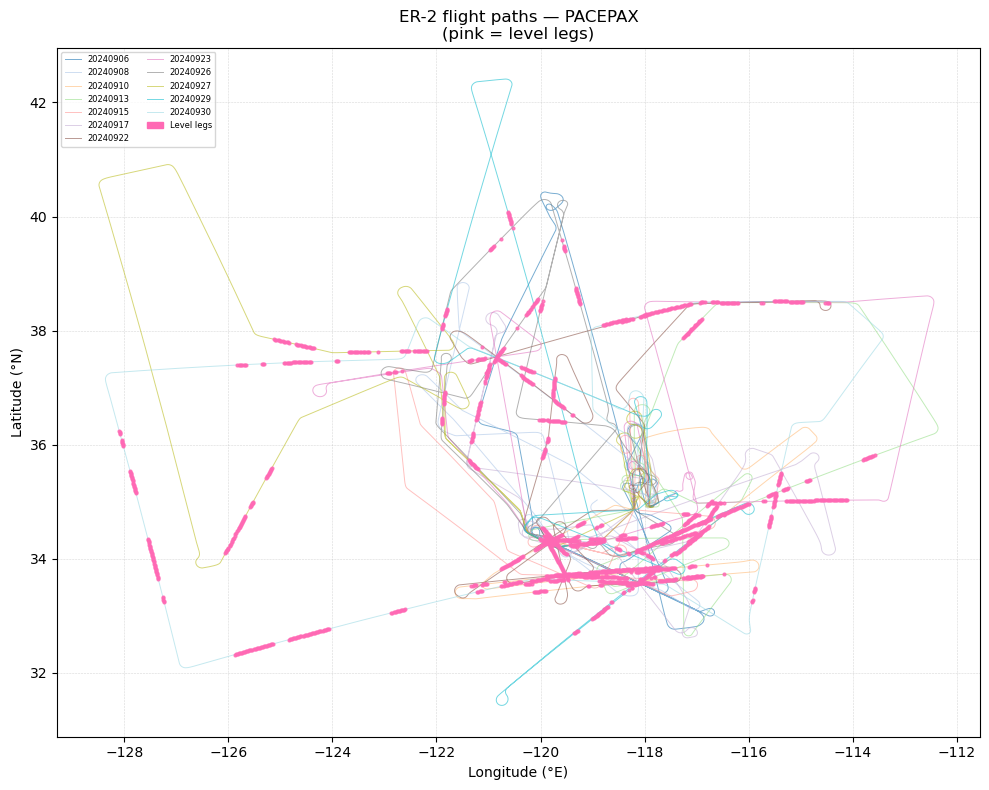

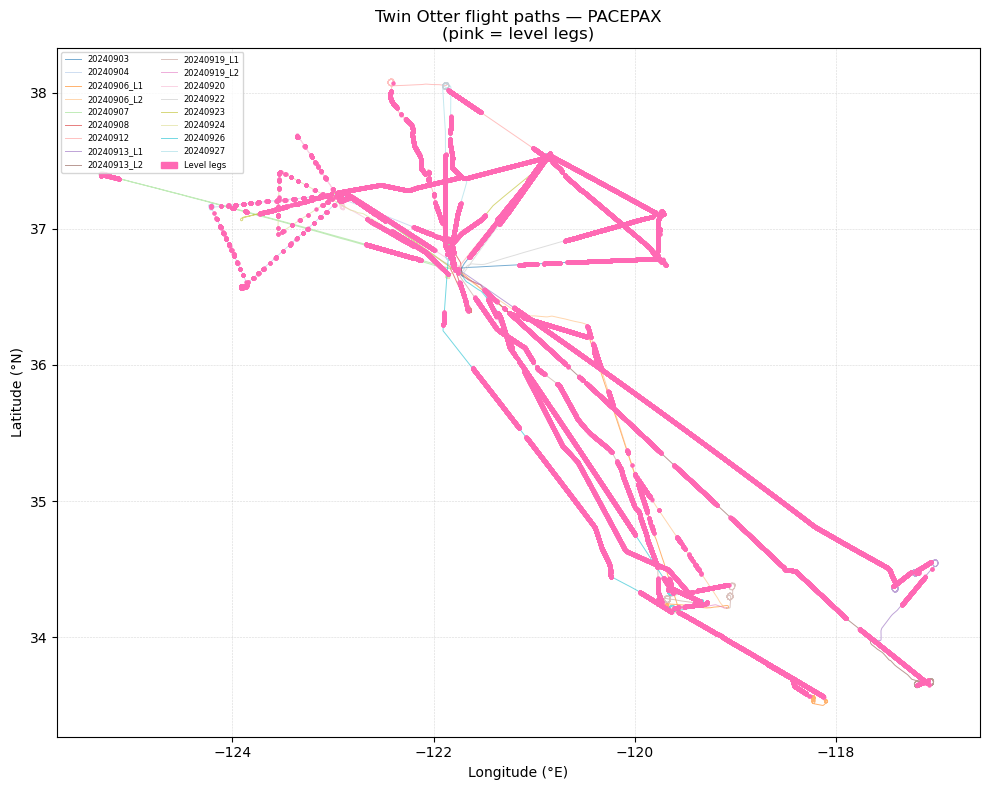

In [94]:
# [CC] Map figures: ER-2 and TO flight paths with level segments highlighted in pink

from IPython.utils.capture import capture_output
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- ER-2 map ---
fig1, ax1 = plt.subplots(figsize=(10, 8))
colors_er2 = plt.cm.tab20(np.linspace(0, 1, len(hs2)))
for i, h in enumerate(hs2):
    lat = h['lat'].flatten()
    lon = h['lon'].flatten()
    fin = np.isfinite(lat) & np.isfinite(lon)
    ax1.plot(lon[fin], lat[fin], color=colors_er2[i], lw=0.7, alpha=0.6,
             label=h.get('daystr', f'day{i}'))

# overlay level legs in pink
for arr_lat, arr_lon in zip(dvals_er2['lat'], dvals_er2['lon']):
    ax1.scatter(arr_lon, arr_lat, s=4, color='hotpink', zorder=5, alpha=0.8)

ax1.set_xlabel('Longitude (°E)')
ax1.set_ylabel('Latitude (°N)')
ax1.set_title('ER-2 flight paths — PACEPAX\n(pink = level legs)')
ax1.grid(True, ls='--', lw=0.4, alpha=0.5)
ax1.legend(fontsize=6, ncol=2, loc='upper left')
pink_patch = mpatches.Patch(color='hotpink', label='Level legs')
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles + [pink_patch], labels + ['Level legs'], fontsize=6, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()

# --- Twin Otter map ---
fig2, ax2 = plt.subplots(figsize=(10, 8))
colors_to = plt.cm.tab20(np.linspace(0, 1, len(to_nav)))
for i, (day, nav) in enumerate(sorted(to_nav.items())):
    lat = np.array(nav['lat'], dtype=float).flatten()
    lon = np.array(nav['lon'], dtype=float).flatten()
    fin = np.isfinite(lat) & np.isfinite(lon)
    ax2.plot(lon[fin], lat[fin], color=colors_to[i], lw=0.7, alpha=0.6, label=day)

# overlay level legs in pink
for arr_lat, arr_lon in zip(dvals_to['lat'], dvals_to['lon']):
    ax2.scatter(arr_lon, arr_lat, s=4, color='hotpink', zorder=5, alpha=0.8)

ax2.set_xlabel('Longitude (°E)')
ax2.set_ylabel('Latitude (°N)')
ax2.set_title('Twin Otter flight paths — PACEPAX\n(pink = level legs)')
ax2.grid(True, ls='--', lw=0.4, alpha=0.5)
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles2 + [pink_patch], labels2 + ['Level legs'], fontsize=6, ncol=2, loc='upper left')
plt.tight_layout()
plt.show()


## Add coastlines

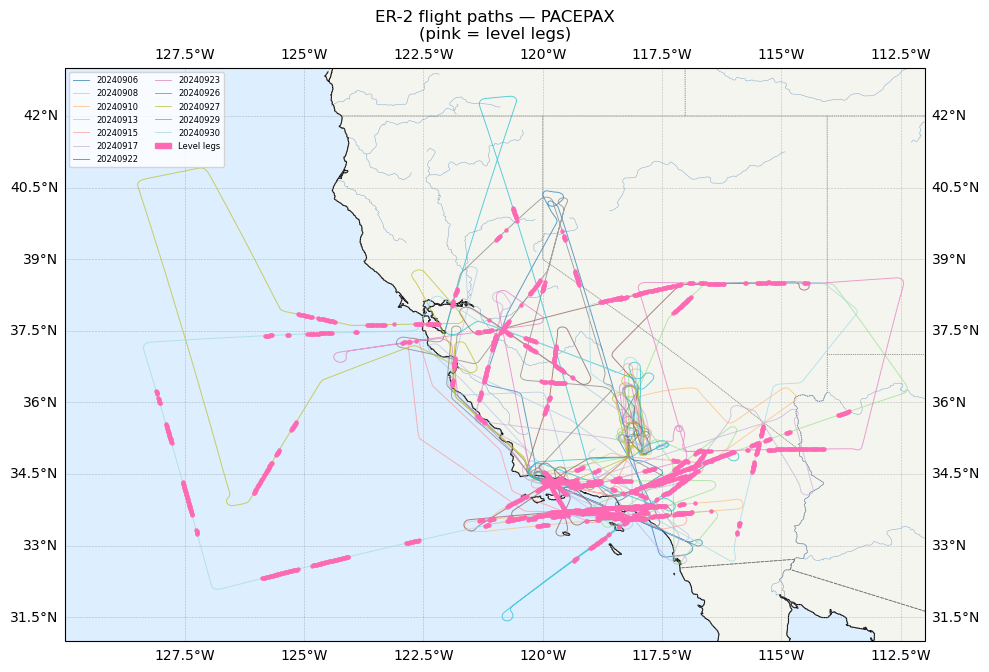

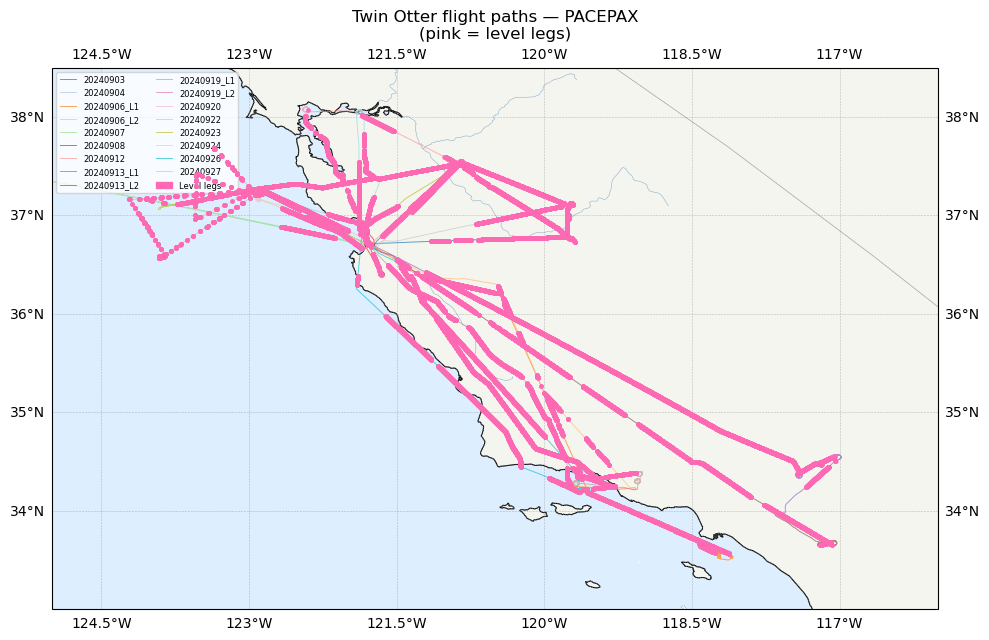

In [103]:
# [CC] Map figures with cartopy coastlines, state borders, and rivers

from IPython.utils.capture import capture_output
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

def add_geo_features(ax):
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='dimgray', linestyle='--')
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray', linestyle=':')
    ax.add_feature(cfeature.RIVERS, linewidth=0.4, edgecolor='steelblue', alpha=0.6)
    ax.add_feature(cfeature.LAND, facecolor='#f5f5f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#ddeeff')
    ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')

# --- ER-2 map ---
fig1, ax1 = plt.subplots(figsize=(10, 8), subplot_kw={'projection': proj})
ax1.set_extent([-130, -112, 31, 43], crs=proj)
add_geo_features(ax1)

colors_er2 = plt.cm.tab20(np.linspace(0, 1, len(hs2)))
for i, h in enumerate(hs2):
    lat = h['lat'].flatten(); lon = h['lon'].flatten()
    fin = np.isfinite(lat) & np.isfinite(lon)
    ax1.plot(lon[fin], lat[fin], color=colors_er2[i], lw=0.7, alpha=0.7,
             transform=proj, label=h.get('daystr', f'day{i}'))

for arr_lat, arr_lon in zip(dvals_er2['lat'], dvals_er2['lon']):
    ax1.scatter(arr_lon, arr_lat, s=5, color='hotpink', zorder=6, alpha=0.9, transform=proj)

pink_patch = mpatches.Patch(color='hotpink', label='Level legs')
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles + [pink_patch], labels + ['Level legs'],
           fontsize=6, ncol=2, loc='upper left')
ax1.set_title('ER-2 flight paths — PACEPAX\n(pink = level legs)')
plt.tight_layout()
plt.show()

# --- Twin Otter map ---
fig2, ax2 = plt.subplots(figsize=(10, 8), subplot_kw={'projection': proj})
ax2.set_extent([-125, -116, 33, 38.5], crs=proj)
add_geo_features(ax2)

colors_to = plt.cm.tab20(np.linspace(0, 1, len(to_nav)))
for i, (day, nav) in enumerate(sorted(to_nav.items())):
    lat = np.array(nav['lat'], dtype=float).flatten()
    lon = np.array(nav['lon'], dtype=float).flatten()
    fin = np.isfinite(lat) & np.isfinite(lon)
    ax2.plot(lon[fin], lat[fin], color=colors_to[i], lw=0.7, alpha=0.7,
             transform=proj, label=day)

for arr_lat, arr_lon in zip(dvals_to['lat'], dvals_to['lon']):
    ax2.scatter(arr_lon, arr_lat, s=5, color='hotpink', zorder=6, alpha=0.9, transform=proj)

handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles2 + [pink_patch], labels2 + ['Level legs'],
           fontsize=6, ncol=2, loc='upper left')
ax2.set_title('Twin Otter flight paths — PACEPAX\n(pink = level legs)')
plt.tight_layout()
plt.show()


# Setup autocorrelation

In [92]:
# 21 log-spaced distance scales (km) — identical to LeBlanc et al. 2022
corr_ks = np.array([0.08, 0.12, 0.18, 0.27, 0.4, 0.6, 0.9, 1.35, 2.0, 3.0,
                    5.0, 7.5, 10.0, 15.0, 25.0, 35.0, 65.0, 100.0, 160.0, 250.0, 380.0])

# Tolerance: ±20% band around each distance bin
dv = 0.20

# Minimum number of pairs required to report an autocorrelation value
min_num = 100

# Monte Carlo parameters
subsamp_ratio = 0.30
N_mc          = 50

print('Distance scales (km):', corr_ks)
print('dv=', dv, '  min_num=', min_num, '  N_mc=', N_mc)

Distance scales (km): [8.00e-02 1.20e-01 1.80e-01 2.70e-01 4.00e-01 6.00e-01 9.00e-01 1.35e+00
 2.00e+00 3.00e+00 5.00e+00 7.50e+00 1.00e+01 1.50e+01 2.50e+01 3.50e+01
 6.50e+01 1.00e+02 1.60e+02 2.50e+02 3.80e+02]
dv= 0.2   min_num= 100   N_mc= 50


## Precompute iis distance-pair index matrices

For each level leg `i` and each distance scale `k`, `iis[i][ik]` gives the row/column
index pairs in the leg where the separation distance falls within `k*(1±dv)` km.
This matrix approach (from the publication) is far faster than searching on the fly.

In [ ]:
print('Precomputing ER-2 iis distance matrices...')
iis_er2 = precompute_iis(dvals_er2, corr_ks, dv=dv)
print('Done. Example iis_er2[0][5]:', iis_er2[0][5] if iis_er2 else 'empty')

In [ ]:
print('Precomputing TO iis distance matrices...')
iis_to = precompute_iis(dvals_to, corr_ks, dv=dv)
print('Done.')

In [ ]:
# Quick sanity check: confirm iis distances match corr_ks
if er2_legs_valid and len(dvals_er2['cumdist']) > 0:
    j = 0
    print('Leg 0 distance checks:')
    for ik, k in enumerate(corr_ks[:5]):
        if iis_er2[j][ik] is None: continue
        rows, cols = iis_er2[j][ik]
        if len(rows) == 0: continue
        cd = dvals_er2['cumdist'][j]
        diffs = cd[cols] - cd[rows]
        print('  k={:.2f} km: actual distances min={:.3f} max={:.3f} mean={:.3f}'.format(
            k, diffs.min(), diffs.max(), diffs.mean()))

## Define data type stratifications (itypes)

For each dvals dict, define index arrays selecting legs by time period and altitude.

In [ ]:
types = ['all','t1','t2','t3','t4','z1','z2','z3']

def make_itypes(dvals, t1, t2, t3, t4, z1, z2, z3):
    'Build 8-element itypes list for the given dvals and time/alt boundaries'
    dn = dvals['doys_n']
    an = dvals['alt_n']
    itypes = [None]*8
    itypes[0], = np.where((dn > 0.0) & np.isfinite(dn))
    itypes[1], = np.where((dn > t1[0]) & (dn < t1[1]))
    itypes[2], = np.where((dn > t2[0]) & (dn < t2[1]))
    itypes[3], = np.where((dn > t3[0]) & (dn < t3[1]))
    itypes[4], = np.where((dn > t4[0]) & (dn < t4[1]))
    itypes[5], = np.where((an > z1[0]) & (an < z1[1]))
    itypes[6], = np.where((an > z2[0]) & (an < z2[1]))
    itypes[7], = np.where((an > z3[0]) & (an < z3[1]))
    return itypes

itypes_er2 = make_itypes(dvals_er2, t1, t2, t3, t4, z1, z2, z3)
itypes_to  = make_itypes(dvals_to,  t1, t2, t3, t4, z1, z2, z3)

print('ER-2 type sizes:', [len(it) for it in itypes_er2])
print('TO  type sizes:', [len(it) for it in itypes_to])

In [ ]:
# Variables and valid value ranges for ER-2
corr_vals_er2  = ['aod532', 'aod355']
range_vals_er2 = {'aod532': [0.0, 3.0], 'aod355': [0.0, 3.0]}

# Variables and valid value ranges for TO
corr_vals_to   = ['uhsas', 'ext532']
range_vals_to  = {'uhsas': [0.0, 20000.0], 'ext532': [0.0, 2000.0]}

# Variables and valid value ranges for PACE
corr_vals_pace = ['aod']
range_vals_pace= {'aod': [0.0, 3.0]}

# Single-run test before multiprocessing

In [ ]:
# Test single variable, single type before committing to full run
from functools import partial

# Bind instrument-specific data to calc_autocorr
calc_er2 = partial(calc_autocorr,
                   types=types, corr_ks=corr_ks,
                   dvals=dvals_er2, iis=iis_er2, itypes=itypes_er2,
                   range_vals=range_vals_er2)

calc_to  = partial(calc_autocorr,
                   types=types, corr_ks=corr_ks,
                   dvals=dvals_to, iis=iis_to, itypes=itypes_to,
                   range_vals=range_vals_to)

test = calc_er2('aod532')
print('Test result shape:', test['c']['aod532'].shape)
print('Type 0 (all), first 5 distances:', test['c']['aod532'][0,:5])

# Run full autocorrelation — ER-2 HSRL-2
This uses multiprocessing. On a 7-CPU server each `calc_autocorr_mc` call takes ~minutes.
Run `calc_autocorr` first (fast) then `calc_autocorr_mc` (slower).

In [ ]:
p = Pool(min(7, cpu_count()), worker_init)

autocorr_er2    = {}
autocorr_len_er2= {}
mean_diff_er2   = {}
std_diff_er2    = {}
median_diff_er2 = {}

with tqdm(total=len(corr_vals_er2)) as pbar:
    for outs in p.imap_unordered(calc_er2, corr_vals_er2):
        pbar.update()
        k = list(outs['c'].keys())[0]
        autocorr_er2[k]     = outs['c'][k]
        autocorr_len_er2[k] = outs['l'][k]
        mean_diff_er2[k]    = outs['mean_diff'][k]
        std_diff_er2[k]     = outs['std_diff'][k]
        median_diff_er2[k]  = outs['median_diff'][k]

print('ER-2 autocorr done')

In [ ]:
calc_er2_mc = partial(calc_autocorr_mc,
                      types=types, corr_ks=corr_ks,
                      dvals=dvals_er2, iis=iis_er2, itypes=itypes_er2,
                      range_vals=range_vals_er2,
                      subsamp_ratio=subsamp_ratio, N_mc=N_mc)

autocorr_mc_er2     = {}
autocorr_len_mc_er2 = {}

with tqdm(total=len(corr_vals_er2)) as pbar:
    for outs in p.imap_unordered(calc_er2_mc, corr_vals_er2):
        pbar.update()
        k = list(outs['c'].keys())[0]
        autocorr_mc_er2[k]     = outs['c'][k]
        autocorr_len_mc_er2[k] = outs['l'][k]

print('ER-2 MC autocorr done')

# Run full autocorrelation — Twin Otter

In [ ]:
calc_to_mc = partial(calc_autocorr_mc,
                     types=types, corr_ks=corr_ks,
                     dvals=dvals_to, iis=iis_to, itypes=itypes_to,
                     range_vals=range_vals_to,
                     subsamp_ratio=subsamp_ratio, N_mc=N_mc)

autocorr_to      = {}
autocorr_len_to  = {}
autocorr_mc_to   = {}
autocorr_len_mc_to = {}

with tqdm(total=len(corr_vals_to)) as pbar:
    for outs in p.imap_unordered(calc_to, corr_vals_to):
        pbar.update()
        k = list(outs['c'].keys())[0]
        autocorr_to[k]    = outs['c'][k]
        autocorr_len_to[k]= outs['l'][k]

with tqdm(total=len(corr_vals_to)) as pbar:
    for outs in p.imap_unordered(calc_to_mc, corr_vals_to):
        pbar.update()
        k = list(outs['c'].keys())[0]
        autocorr_mc_to[k]     = outs['c'][k]
        autocorr_len_mc_to[k] = outs['l'][k]

print('TO autocorr done')

# PACE satellite autocorrelation

Each Level-2 granule swath is treated as a set of legs (one per along-track row).
The same `mat_dist`/`iis` precomputation approach is used.

In [ ]:
def sat_to_dvals(granule_list, qa_min=1):
    """
    Convert PACE L2 granule list into a dvals-compatible dict.
    Each valid along-track row (or entire 1-D granule) becomes one leg.
    Cumulative distance is computed along the row using spherical_dist.
    """
    d = {'lat':[],'lon':[],'aod':[],'angstrom':[],'utc':[],'doys':[],
         'cumdist':[],'dist':[],'doys_n':[],'alt_n':[],'len_minutes':[],'len_doys':[]}

    for g in granule_list:
        lat = g['lat']
        lon = g['lon']
        aod = g['aod']
        ang = g.get('angstrom', np.full_like(aod, np.nan))
        qa  = g.get('qa', np.ones_like(aod, dtype=int))
        doy = g.get('doy', np.nan)

        def _add_row(la, lo, av, an, qa_r):
            good = np.isfinite(av) & (av >= 0) & (qa_r >= qa_min)
            if good.sum() < 5: return
            la, lo, av, an = la[good], lo[good], av[good], an[good]
            cd = np.zeros(len(la))
            for jj in range(1, len(la)):
                cd[jj] = cd[jj-1] + mu.spherical_dist([la[jj-1],lo[jj-1]], [la[jj],lo[jj]])
            # fake utc as index for compatibility
            t = np.arange(len(la), dtype=float)
            d['lat'].append(la); d['lon'].append(lo); d['aod'].append(av)
            d['angstrom'].append(an); d['utc'].append(t)
            d['cumdist'].append(cd); d['dist'].append(np.diff(cd))
            d['doys'].append(np.full(len(la), doy))
            d['doys_n'].append(doy); d['alt_n'].append(0.0)
            d['len_minutes'].append(np.nan); d['len_doys'].append(np.nan)

        if lat.ndim == 2:
            for row in range(lat.shape[0]):
                _add_row(lat[row], lon[row], aod[row], ang[row], qa[row])
        else:
            _add_row(lat, lon, aod, ang, qa)

    for k in list(d.keys()):
        d[k] = np.array(d[k], dtype=object)
    return d

print('sat_to_dvals defined')

In [ ]:
dvals_oci   = sat_to_dvals(oci)
dvals_harp2 = sat_to_dvals(harp2)
dvals_spex  = sat_to_dvals(spex)

print('OCI legs:    ', len(dvals_oci['lat']))
print('HARP2 legs:  ', len(dvals_harp2['lat']))
print('SPEXone legs:', len(dvals_spex['lat']))

In [ ]:
print('Precomputing PACE iis matrices (may take a few minutes)...')
iis_oci   = precompute_iis(dvals_oci,   corr_ks, dv=dv)
iis_harp2 = precompute_iis(dvals_harp2, corr_ks, dv=dv)
iis_spex  = precompute_iis(dvals_spex,  corr_ks, dv=dv)
print('Done.')

In [ ]:
# Single itypes for satellite: type 0 = all (no altitude/time stratification)
def make_itypes_sat(dvals):
    itypes = [None]*8
    n = len(dvals['cumdist'])
    all_idx = np.arange(n)
    for ii in range(8):
        itypes[ii] = all_idx  # fill all types with all data; refine if needed
    return itypes

itypes_oci   = make_itypes_sat(dvals_oci)
itypes_harp2 = make_itypes_sat(dvals_harp2)
itypes_spex  = make_itypes_sat(dvals_spex)

In [ ]:
calc_oci   = partial(calc_autocorr_mc, types=types, corr_ks=corr_ks,
                     dvals=dvals_oci,   iis=iis_oci,   itypes=itypes_oci,
                     range_vals=range_vals_pace, subsamp_ratio=subsamp_ratio, N_mc=N_mc)
calc_harp2 = partial(calc_autocorr_mc, types=types, corr_ks=corr_ks,
                     dvals=dvals_harp2, iis=iis_harp2, itypes=itypes_harp2,
                     range_vals=range_vals_pace, subsamp_ratio=subsamp_ratio, N_mc=N_mc)
calc_spex  = partial(calc_autocorr_mc, types=types, corr_ks=corr_ks,
                     dvals=dvals_spex,  iis=iis_spex,  itypes=itypes_spex,
                     range_vals=range_vals_pace, subsamp_ratio=subsamp_ratio, N_mc=N_mc)

autocorr_mc_oci   = {}; autocorr_mc_harp2 = {}; autocorr_mc_spex = {}

for calc_fn, store, label in [
        (calc_oci,   autocorr_mc_oci,   'OCI'),
        (calc_harp2, autocorr_mc_harp2, 'HARP2'),
        (calc_spex,  autocorr_mc_spex,  'SPEXone')]:
    outs = calc_fn('aod')
    k = list(outs['c'].keys())[0]
    store[k] = outs['c'][k]
    print(label, 'done, shape:', store[k].shape)

# Combine results and compute mean/std statistics

In [ ]:
def mc_stats(mc_dict):
    'Compute mean and std over MC iterations (axis=-1) for all variables'
    mm = {k: np.nanmean(v, axis=-1) for k,v in mc_dict.items()}
    dm = {k: np.nanstd(v,  axis=-1) for k,v in mc_dict.items()}
    return mm, dm

autocorr_mm_er2, autocorr_dm_er2   = mc_stats(autocorr_mc_er2)
autocorr_mm_to,  autocorr_dm_to    = mc_stats(autocorr_mc_to)
autocorr_mm_oci, autocorr_dm_oci   = mc_stats(autocorr_mc_oci)
autocorr_mm_h2,  autocorr_dm_h2    = mc_stats(autocorr_mc_harp2)
autocorr_mm_spx, autocorr_dm_spx   = mc_stats(autocorr_mc_spex)
print('MC stats computed')

# Save all autocorrelation results

In [ ]:
dat_save = {
    'corr_ks':         corr_ks,
    'types':           np.array(types),
    # ER-2
    'autocorr_er2':     wu.iterate_dict_unicode(autocorr_er2),
    'autocorr_mc_er2':  wu.iterate_dict_unicode(autocorr_mc_er2),
    'mean_diff_er2':    wu.iterate_dict_unicode(mean_diff_er2),
    'std_diff_er2':     wu.iterate_dict_unicode(std_diff_er2),
    'median_diff_er2':  wu.iterate_dict_unicode(median_diff_er2),
    # TO
    'autocorr_to':      wu.iterate_dict_unicode(autocorr_to),
    'autocorr_mc_to':   wu.iterate_dict_unicode(autocorr_mc_to),
    # PACE
    'autocorr_mc_oci':  wu.iterate_dict_unicode(autocorr_mc_oci),
    'autocorr_mc_harp2':wu.iterate_dict_unicode(autocorr_mc_harp2),
    'autocorr_mc_spex': wu.iterate_dict_unicode(autocorr_mc_spex),
}
hs.savemat(os.path.join(fp, 'PACEPAX_autocorr_{}.mat'.format(vv)), dat_save)
print('Saved to:', os.path.join(fp, 'PACEPAX_autocorr_{}.mat'.format(vv)))

In [ ]:
# Load (run instead of the run sections when restarting)
# dat = hs.loadmat(os.path.join(fp, 'PACEPAX_autocorr_{}.mat'.format(vv)))
# corr_ks          = dat['corr_ks']
# autocorr_mc_er2  = dat['autocorr_mc_er2']
# autocorr_mc_to   = dat['autocorr_mc_to']
# autocorr_mc_oci  = dat['autocorr_mc_oci']
# autocorr_mc_harp2= dat['autocorr_mc_harp2']
# autocorr_mc_spex = dat['autocorr_mc_spex']
# autocorr_mm_er2, autocorr_dm_er2 = mc_stats(autocorr_mc_er2)
# autocorr_mm_to,  autocorr_dm_to  = mc_stats(autocorr_mc_to)
# autocorr_mm_oci, autocorr_dm_oci = mc_stats(autocorr_mc_oci)
# autocorr_mm_h2,  autocorr_dm_h2  = mc_stats(autocorr_mc_harp2)
# autocorr_mm_spx, autocorr_dm_spx = mc_stats(autocorr_mc_spex)

# Decorrelation length scales

In [ ]:
# Print e-folding, 85th and 90th percentile distances for all variables, type 0 (all data)
jj = 2  # start from this index to skip noisy very-short scales
j  = 0  # type index: 0 = all data

print('=== Decorrelation lengths (type: all, starting from k index {}) ==='.format(jj))
for label, mm, dm, var in [
    ('HSRL-2 AOD532 (ER-2)', autocorr_mm_er2, autocorr_dm_er2, 'aod532'),
    ('HSRL-2 AOD355 (ER-2)', autocorr_mm_er2, autocorr_dm_er2, 'aod355'),
    ('TO UHSAS N',           autocorr_mm_to,  autocorr_dm_to,  'uhsas'),
    ('TO ext532',            autocorr_mm_to,  autocorr_dm_to,  'ext532'),
    ('PACE OCI AOD',         autocorr_mm_oci, autocorr_dm_oci, 'aod'),
    ('PACE HARP2 AOD',       autocorr_mm_h2,  autocorr_dm_h2,  'aod'),
    ('PACE SPEXone AOD',     autocorr_mm_spx, autocorr_dm_spx, 'aod'),
]:
    if var not in mm: continue
    print('\n' + label)
    print_autocorr_stats(var, mm, dm, j, jj)

In [ ]:
# Decorrelation lengths by time/altitude type for ER-2 AOD532
print('ER-2 AOD532 decorrelation by type:')
legend_list = ['All','Early Sep (t1)','First smoke (t2)','Second smoke (t3)','Late Sep (t4)',
               '0-0.5 km','0.5-3 km','15-22 km']
for j, jt in enumerate(types):
    if len(itypes_er2[j]) < 5: continue
    if 'aod532' not in autocorr_mm_er2: break
    ac = autocorr_mm_er2['aod532'][j, jj:]
    if not np.isfinite(ac).any(): continue
    p85 = percentile_autocorr(ac, 0.85)
    pe  = e_folding_autocorr(ac)
    print('  {}: 85%={} km  e-fold={} km'.format(legend_list[j], p85, pe))

# Overview plots

In [ ]:
# Flight tracks and level legs map
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for ax, title in zip(axes, ['ER-2 HSRL-2', 'Twin Otter']):
    ax.set_extent([lon_rg[0], lon_rg[1], lat_rg[0], lat_rg[1]])
    ax.add_feature(cfeature.LAND,      facecolor='lightgrey', zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor='lightblue', zorder=0)
    ax.add_feature(cfeature.COASTLINE, lw=0.8)
    ax.add_feature(cfeature.STATES,    linestyle=':', lw=0.5, alpha=0.5)
    gl = ax.gridlines(draw_labels=True, lw=0.4, color='grey', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    ax.set_title(title)

for h in hs2:
    fl = h['fl_good']
    axes[0].plot(h['lon'][fl], h['lat'][fl], '.', ms=0.3, color='grey', alpha=0.3, transform=ccrs.PlateCarree())
for segs in er2_legs_valid:
    for ii in segs.get('keep_idx', []):
        axes[0].plot(segs['lon'][ii], segs['lat'][ii], '-', lw=1.5, transform=ccrs.PlateCarree())

for k, nav in to_nav.items():
    fl = nav['fl_good']
    axes[1].plot(nav['lon'][fl], nav['lat'][fl], '.', ms=0.3, color='grey', alpha=0.3, transform=ccrs.PlateCarree())
for k, segs in to_legs.items():
    for ii in segs.get('keep_idx', []):
        axes[1].plot(segs['lon'][ii], segs['lat'][ii], '-', lw=1.5, transform=ccrs.PlateCarree())

plt.suptitle('PACE-PAX Sep 2024 — flight tracks (grey) and level legs (colour)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(fp, 'PACEPAX_flight_tracks_{}.png'.format(vv)), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# PACE AOD spatial coverage (all three instruments)
fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()})
for ax, (dset, label) in zip(axes, [(oci,'OCI AOD$_{550}$'),(harp2,'HARP2 AOD'),(spex,'SPEXone AOD')]):
    ax.set_extent([lon_rg[0], lon_rg[1], lat_rg[0], lat_rg[1]])
    ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=0)
    ax.add_feature(cfeature.COASTLINE, lw=0.8)
    ax.add_feature(cfeature.STATES, linestyle=':', lw=0.4, alpha=0.5)
    sc = None
    for g in dset:
        good = np.isfinite(g['aod']) & (g['aod'] >= 0)
        if not good.any(): continue
        sc = ax.scatter(g['lon'][good], g['lat'][good], c=g['aod'][good],
                        s=0.5, cmap='viridis', vmin=0, vmax=0.6, transform=ccrs.PlateCarree())
    if sc is not None:
        plt.colorbar(sc, ax=ax, label='AOD', shrink=0.7)
    gl = ax.gridlines(draw_labels=True, lw=0.4, linestyle='--', color='grey', alpha=0.5)
    gl.top_labels = False; gl.right_labels = False
    ax.set_title(label)
plt.suptitle('PACE-PAX Sep 2024 — satellite AOD coverage')
plt.tight_layout()
plt.savefig(os.path.join(fp, 'PACEPAX_PACE_AOD_map_{}.png'.format(vv)), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Histogram of leg lengths
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, dv_dict, title in [
        (axes[0], dvals_er2, 'ER-2 HSRL-2'),
        (axes[1], dvals_to,  'Twin Otter')]:
    lkm = np.array([cd[-1] if np.isfinite(cd).any() else np.nan
                    for cd in dv_dict['cumdist']])
    lmin = dv_dict['len_minutes']
    ax.hist(lkm[np.isfinite(lkm)], bins=30, edgecolor='k', lw=0.5)
    ax.set_xlabel('Leg length [km]')
    ax.set_ylabel('Count')
    ax.set_title(title + ' — {:d} legs'.format(np.isfinite(lkm).sum()))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fp, 'PACEPAX_leg_lengths_{}.png'.format(vv)), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Point-separation distance distribution (from iis precomputation)
alldist_er2 = np.hstack([d for d in dvals_er2['dist'] if np.isfinite(d).any()])
alldist_to  = np.hstack([d for d in dvals_to['dist']  if np.isfinite(d).any()])
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(alldist_er2, bins=100, range=[0,5], alpha=0.6, label='ER-2', density=True)
ax.hist(alldist_to,  bins=100, range=[0,5], alpha=0.6, label='TO',   density=True)
ax.set_xlabel('Distance between consecutive points [km]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Autocorrelation plots

## Main autocorrelation plot — all instruments, type 0 (all data)

In [ ]:
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 5))
jj = 0  # start index for plotting
j  = 0  # type: all data

cl = ['tab:blue','tab:cyan','tab:green','tab:olive','tab:orange','tab:red','tab:purple']

plot_sets = [
    (autocorr_mm_er2, autocorr_dm_er2, 'aod532',  'HSRL-2 AOD$_{532}$',   cl[0], '-o'),
    (autocorr_mm_er2, autocorr_dm_er2, 'aod355',  'HSRL-2 AOD$_{355}$',   cl[1], '--o'),
    (autocorr_mm_to,  autocorr_dm_to,  'uhsas',   'TO UHSAS N$_{100-1000}$', cl[2], '-s'),
    (autocorr_mm_to,  autocorr_dm_to,  'ext532',  'TO ext$_{532}$',        cl[3], '--s'),
]
pace_sets = [
    (autocorr_mm_oci, autocorr_dm_oci, 'aod', 'PACE OCI AOD',     cl[4], '-^'),
    (autocorr_mm_h2,  autocorr_dm_h2,  'aod', 'PACE HARP2 AOD',   cl[5], '-D'),
    (autocorr_mm_spx, autocorr_dm_spx, 'aod', 'PACE SPEXone AOD', cl[6], '-P'),
]

for ax_i, (sets, title) in enumerate([(plot_sets,'Airborne'),(pace_sets,'PACE Satellite')]):
    for mm, dm, var, label, color, fmt in sets:
        if var not in mm: continue
        ac = mm[var][j, jj:]
        er = dm[var][j, jj:]
        good = np.isfinite(ac)
        if not good.any(): continue
        ax[ax_i].errorbar(corr_ks[jj:][good], ac[good], yerr=er[good],
                          fmt=fmt, color=color, label=label, lw=1.5, ms=5, elinewidth=0.6)
        # 85th percentile decorrelation line
        p85 = percentile_autocorr(ac[good], 0.85) if good.any() else np.nan
        if np.isfinite(p85):
            ax[ax_i].axvline(p85, ls=':', color=color, lw=0.8)
    ax[ax_i].axhline(0, ls='--', color='grey', alpha=0.4, lw=0.8)
    ax[ax_i].set_xscale('log')
    ax[ax_i].set_xlabel('Separation distance [km]')
    ax[ax_i].set_ylim(-0.1, 1.05)
    ax[ax_i].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax[ax_i].set_title(title)
    ax[ax_i].legend(frameon=False, fontsize=8)
    ax[ax_i].grid(True, which='both', alpha=0.3)

ax[0].set_ylabel('Autocorrelation')
plt.suptitle('PACE-PAX Sep 2024 — Spatial aerosol autocorrelation (all data, dotted lines = 85th percentile)')
plt.tight_layout()
plt.savefig(os.path.join(fp, 'PACEPAX_autocorr_main_{}.png'.format(vv)),   dpi=600, transparent=True)
plt.savefig(os.path.join(fp, 'PACEPAX_autocorr_main_{}.pdf'.format(vv)),   dpi=600, transparent=True)
plt.show()

## Normalized autocorrelation by meteorological period (ER-2 AOD532)

In [ ]:
cl_list = ['k','tab:red','tab:blue','tab:orange','tab:green','tab:olive','tab:cyan','tab:purple']
m_list  = ['o','s','D','^','v','<','>','P']
jj_norm = 1  # normalise to r at this index

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(11, 4.5))

for ax_i, (key, title) in enumerate([('aod532','ER-2 HSRL-2 AOD$_{532}$'),
                                      ('uhsas',  'TO UHSAS N$_{100-1000}$')]):
    mm = autocorr_mm_er2 if 'er2' in key or key=='aod532' else autocorr_mm_to
    dm = autocorr_dm_er2 if key=='aod532' else autocorr_dm_to
    if key not in mm: continue
    for j, jt in enumerate(types):
        ac  = mm[key][j, jj_norm:]
        std = dm[key][j, jj_norm:]
        r0  = ac[0]
        if not np.isfinite(r0) or r0 == 0: continue
        ac_norm  = ac  / r0
        std_norm = std / r0
        good = np.isfinite(ac_norm)
        axes[ax_i].plot(corr_ks[jj_norm:][good], ac_norm[good],
                        color=cl_list[j], marker=m_list[j], lw=1.2, ms=4, alpha=0.8,
                        label=legend_list[j])
        axes[ax_i].errorbar(corr_ks[jj_norm:][good]*(0.95 + j*0.01),
                            ac_norm[good], yerr=std_norm[good],
                            color=cl_list[j], ls='none', capsize=1.5, elinewidth=0.5)
    axes[ax_i].axhline(0, ls='--', color='grey', alpha=0.4)
    axes[ax_i].set_xscale('log')
    axes[ax_i].set_ylim(-0.1, 1.15)
    axes[ax_i].set_xlabel('Distance [km]')
    axes[ax_i].set_title(title)
    axes[ax_i].grid(True, which='both', alpha=0.3)

axes[0].set_ylabel('Normalized autocorrelation r(d)/r(d$_0$)')
axes[0].legend(frameon=False, fontsize=8)
plt.suptitle('PACE-PAX — Normalized autocorrelation by time/altitude type')
plt.tight_layout()
plt.savefig(os.path.join(fp, 'PACEPAX_autocorr_norm_types_{}.png'.format(vv)), dpi=600, transparent=True)
plt.show()

## Mean/std difference vs. distance (Table equivalent)

In [ ]:
elements_er2 = [v for v in ['aod532','aod355'] if v in mean_diff_er2]
if elements_er2:
    fig, axes = plt.subplots(len(elements_er2), 1, sharex=True, figsize=(6, 3*len(elements_er2)))
    if len(elements_er2)==1: axes = [axes]
    for ax, var in zip(axes, elements_er2):
        ax.plot(corr_ks, mean_diff_er2[var][0],   label='mean',   lw=1.5)
        ax.plot(corr_ks, median_diff_er2[var][0],  label='median', lw=1.5)
        ax.plot(corr_ks, std_diff_er2[var][0],     label='std',    lw=1.5)
        ax.set_ylabel(r'$x_j - x_{j+k}$')
        ax.set_title('ER-2 {} — all PACE-PAX'.format(var))
        ax.legend(frameon=False)
        ax.set_xscale('log'); ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Lag distance [km]')
    plt.tight_layout()
    plt.savefig(os.path.join(fp, 'PACEPAX_diff_ER2_{}.png'.format(vv)), dpi=300, transparent=True)
    plt.show()

## Decorrelation length summary bar chart

In [ ]:
j   = 0   # all-data type
jj2 = 2   # skip first two distance bins for decorr calc

bars = []
for mm, dm, var, label in [
    (autocorr_mm_er2, autocorr_dm_er2, 'aod532',  'HSRL-2\nAOD$_{532}$'),
    (autocorr_mm_er2, autocorr_dm_er2, 'aod355',  'HSRL-2\nAOD$_{355}$'),
    (autocorr_mm_to,  autocorr_dm_to,  'uhsas',   'TO\nUHSAS N'),
    (autocorr_mm_to,  autocorr_dm_to,  'ext532',  'TO\next$_{532}$'),
    (autocorr_mm_oci, autocorr_dm_oci, 'aod',     'OCI\nAOD'),
    (autocorr_mm_h2,  autocorr_dm_h2,  'aod',     'HARP2\nAOD'),
    (autocorr_mm_spx, autocorr_dm_spx, 'aod',     'SPEXone\nAOD'),
]:
    if var not in mm: bars.append((label, np.nan, np.nan, np.nan)); continue
    ac  = mm[var][j, jj2:]
    std = dm[var][j, jj2:]
    p85 = percentile_autocorr(ac, 0.85) if np.isfinite(ac).any() else np.nan
    p85p= percentile_autocorr(ac+std, 0.85) if np.isfinite(ac).any() else np.nan
    p85m= percentile_autocorr(ac-std, 0.85) if np.isfinite(ac).any() else np.nan
    bars.append((label, p85, abs(p85-p85p), abs(p85-p85m)))

labels = [b[0] for b in bars]
p85s   = [b[1] for b in bars]
p85ep  = [b[2] for b in bars]
p85em  = [b[3] for b in bars]

fig, ax = plt.subplots(figsize=(10, 4))
xpos = np.arange(len(labels))
colors_bar = ['tab:blue','tab:cyan','tab:green','tab:olive','tab:orange','tab:red','tab:purple']
bars_h = ax.bar(xpos, p85s, color=colors_bar, alpha=0.7, edgecolor='k', lw=0.5)
ax.errorbar(xpos, p85s,
            yerr=[p85em, p85ep],
            fmt='none', color='k', capsize=4, lw=1.2)
ax.set_xticks(xpos)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('85th percentile decorrelation length [km]')
ax.set_yscale('log')
ax.set_title('PACE-PAX Sep 2024 — Aerosol decorrelation scales')
ax.grid(True, which='both', axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(fp, 'PACEPAX_decorr_lengths_bar_{}.png'.format(vv)), dpi=300, transparent=True)
plt.show()